# S3MambaDA Updated Research Notebook

This notebook is aligned with the updated project code. It records the 0.5–3.5 s crop, 750-sample input, bidirectional GRU temporal module, GRL + SupCon domain adaptation, and AdaBN. It also provides a publication-safe evaluation mode.

In [6]:
# ============================================================
# S3MambaDA
# FINAL TWO-CLASS LEFT-HAND vs RIGHT-HAND MASTER BLOCK
# ============================================================
#
# Dataset:
#   PhysioNet EEGMMIDB
#
# Classes:
#   0 = Left Fist
#   1 = Right Fist
#
# Runs:
#   4, 8, 12 ONLY
#
# Input:
#   22 EEG channels
#   250 Hz
#   0.5 s -> 3.5 s
#   3.0 seconds
#   750 samples
#
# Architecture:
#   Raw EEG
#      |
#      v
#   Per-trial Channel-wise Z-score
#      |
#      v
#   Learnable Sinc Filter Bank
#      |
#      v
#   Dynamic Graph Neural Network
#      |
#      v
#   Frequency Mean Pooling
#      |
#      v
#   Bidirectional GRU
#      |
#      v
#   SE Attention
#      |
#      +-----------------------+
#      |           |           |
#      v           v           v
#   Classifier    GRL       SupCon
#      |           |           |
#      v           v           v
#   Left/Right   Subject ID   128-D
#
# Test:
#   AdaBN
#
# NOTE:
#   "SimplifiedBiMamba" is the original class name,
#   but its implementation is BIDIRECTIONAL GRU.
#   It is not a true Mamba state-space model.
#
# NO diffusion augmentation is implemented.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import os
import math
import json
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.manifold import TSNE


warnings.filterwarnings("ignore")

mne.set_log_level("ERROR")


# ============================================================
# 1. GLOBAL CONFIGURATION
# ============================================================

SEED = 42

DATA_DIR = "./eegmmidb"


# ============================================================
# DATASET SETTINGS
# ============================================================

TOTAL_SUBJECTS = 109

NUM_TRAIN_SUBJECTS = 99

NUM_TEST_FOLDS = 10


# ============================================================
# TWO-CLASS SETTINGS
# ============================================================

NUM_CLASSES = 2

CLASS_NAMES = [
    "Left Fist",
    "Right Fist"
]


# IMPORTANT:
# Only unilateral hand motor imagery runs.

RUNS = [
    4,
    8,
    12
]


# ============================================================
# EEG SETTINGS
# ============================================================

FS = 250.0

N_CHANNELS = 22

TMIN = 0.5

TMAX = 3.5

TRIAL_DURATION = TMAX - TMIN

N_SAMPLES = int(
    round(
        TRIAL_DURATION * FS
    )
)


assert N_SAMPLES == 750, (
    f"Expected 750 samples, "
    f"but got {N_SAMPLES}"
)


# ============================================================
# TRAINING SETTINGS
# ============================================================

BATCH_SIZE = 64

EPOCHS = 100

LEARNING_RATE = 1e-3

WEIGHT_DECAY = 1e-4

LABEL_SMOOTHING = 0.1

DOMAIN_WEIGHT = 1.0

SUPCON_WEIGHT = 0.5

SUPCON_TEMPERATURE = 0.07

GRADIENT_CLIP = 1.0


# ============================================================
# MODEL SETTINGS
# ============================================================

NUM_FILTERS = 10

SINC_KERNEL_SIZE = 81

SPATIAL_DIM = 64


# ============================================================
# EVALUATION MODE
# ============================================================
#
# PROJECT
#   Reproduces your existing ten target subjects.
#
# RANDOM
#   Selects ten targets reproducibly.
#
# EXHAUSTIVE
#   Every subject becomes a target.
#
# ============================================================

EVAL_MODE = "PROJECT"


CURATED_TEST_POOL = [
    4,
    15,
    23,
    29,
    31,
    42,
    55,
    71,
    95,
    82
    
]


# ============================================================
# OUTPUT DIRECTORIES
# ============================================================

RESULTS_DIR = Path(
    "./results_s3mambada_2class"
)

FIG_DIR = (
    RESULTS_DIR
    / "figures"
)


RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

def seed_everything(
    seed=SEED
):

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )


    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )


seed_everything()


# ============================================================
# 3. DEVICE
# ============================================================

if torch.cuda.is_available():

    DEVICE = torch.device(
        "cuda"
    )

elif torch.backends.mps.is_available():

    DEVICE = torch.device(
        "mps"
    )

else:

    DEVICE = torch.device(
        "cpu"
    )


print("=" * 80)

print(
    "S3MambaDA "
    "TWO-CLASS LEFT/RIGHT HAND PIPELINE"
)

print("=" * 80)

print(
    f"Device: {DEVICE}"
)

print(
    f"Input shape: "
    f"({N_CHANNELS}, {N_SAMPLES})"
)

print(
    f"Sampling rate: "
    f"{FS} Hz"
)

print(
    f"Window: "
    f"{TMIN} s -> {TMAX} s"
)

print(
    f"Classes: "
    f"{CLASS_NAMES}"
)

print(
    f"Runs: "
    f"{RUNS}"
)

print("=" * 80)


# ============================================================
# 4. MNE EVENT HANDLING
# ============================================================

def normalize_annotation_name(
    name
):

    if name is None:

        return ""

    return str(
        name
    ).strip().upper()


def get_actual_event_ids(
    raw
):

    """
    Critical fix.

    MNE assigns numerical event IDs dynamically from the
    annotation descriptions.

    Therefore we MUST NOT assume:

        T1 = 0
        T2 = 1

    We discover the actual IDs first.
    """


    events, event_dict = \
        mne.events_from_annotations(
            raw,
            verbose=False
        )


    normalized_event_dict = {}


    for key, value in event_dict.items():

        normalized_event_dict[
            normalize_annotation_name(
                key
            )
        ] = value


    t1_id = \
        normalized_event_dict.get(
            "T1",
            None
        )


    t2_id = \
        normalized_event_dict.get(
            "T2",
            None
        )


    return (
        events,
        normalized_event_dict,
        t1_id,
        t2_id
    )


# ============================================================
# 5. TWO-CLASS EEGMMIDB DATASET
# ============================================================

class EEGMMIDB_Dataset(
    Dataset
):


    def __init__(
        self,
        data_dir,
        subjects,
        runs=RUNS,
        tmin=TMIN,
        tmax=TMAX
    ):

        self.data_dir = str(
            data_dir
        )

        self.subjects = list(
            subjects
        )

        self.runs = list(
            runs
        )

        self.tmin = tmin

        self.tmax = tmax


        self.epochs = []

        self.labels = []

        self.subject_ids = []

        self.run_ids = []


        self.load_data()


    # ========================================================
    # LOAD DATA
    # ========================================================

    def load_data(
        self
    ):

        print(
            "\nLoading subjects:",
            self.subjects
        )


        for subject in self.subjects:

            subject_folder = (
                f"S{subject:03d}"
            )


            subject_path = os.path.join(
                self.data_dir,
                subject_folder
            )


            if not os.path.exists(
                subject_path
            ):

                print(
                    f"[WARNING] "
                    f"Missing "
                    f"{subject_folder}"
                )

                continue


            for run in self.runs:

                edf_file = os.path.join(
                    subject_path,
                    f"{subject_folder}"
                    f"R{run:02d}.edf"
                )


                if not os.path.exists(
                    edf_file
                ):

                    print(
                        f"[WARNING] "
                        f"Missing "
                        f"{subject_folder}"
                        f"R{run:02d}.edf"
                    )

                    continue


                # ====================================================
                # FOR RUNS 4/8/12:
                #
                # T1 = LEFT FIST
                # T2 = RIGHT FIST
                # ====================================================

                t1_class = 0

                t2_class = 1


                try:

                    # ==================================================
                    # LOAD EDF
                    # ==================================================

                    raw = mne.io.read_raw_edf(
                        edf_file,
                        preload=True,
                        verbose=False
                    )


                    # ==================================================
                    # CHANNEL CHECK
                    # ==================================================

                    if len(
                        raw.ch_names
                    ) < N_CHANNELS:

                        print(
                            f"[WARNING] "
                            f"{subject_folder}"
                            f"R{run:02d}: "
                            f"only "
                            f"{len(raw.ch_names)} "
                            f"channels"
                        )

                        continue


                    # ==================================================
                    # FIRST 22 CHANNELS
                    # ==================================================

                    raw.pick(
                        raw.ch_names[
                            :N_CHANNELS
                        ]
                    )


                    # ==================================================
                    # RESAMPLE TO 250 Hz
                    # ==================================================

                    raw.resample(
                        FS,
                        npad="auto"
                    )


                    # ==================================================
                    # DISCOVER ACTUAL MNE EVENT IDS
                    # ==================================================

                    (
                        events,
                        event_dict,
                        t1_id,
                        t2_id
                    ) = get_actual_event_ids(
                        raw
                    )


                    # ==================================================
                    # VERIFY EVENTS
                    # ==================================================

                    if (
                        t1_id is None
                        or
                        t2_id is None
                    ):

                        print(
                            f"[WARNING] "
                            f"{subject_folder}"
                            f"R{run:02d}: "
                            f"T1/T2 not found"
                        )

                        print(
                            "Available "
                            "annotations:",
                            list(
                                event_dict.keys()
                            )
                        )

                        continue


                    # ==================================================
                    # EXTRACT T1
                    # ==================================================

                    t1_events = events[
                        events[:, 2]
                        ==
                        t1_id
                    ].copy()


                    # ==================================================
                    # EXTRACT T2
                    # ==================================================

                    t2_events = events[
                        events[:, 2]
                        ==
                        t2_id
                    ].copy()


                    if (
                        len(t1_events) == 0
                        or
                        len(t2_events) == 0
                    ):

                        print(
                            f"[WARNING] "
                            f"{subject_folder}"
                            f"R{run:02d}: "
                            f"T1={len(t1_events)} "
                            f"T2={len(t2_events)}"
                        )

                        continue


                    # ==================================================
                    # REMAP TO 0/1
                    # ==================================================

                    selected_events = []


                    # T1 -> Left Fist = 0

                    for event in t1_events:

                        new_event = \
                            event.copy()

                        new_event[2] = \
                            t1_class

                        selected_events.append(
                            new_event
                        )


                    # T2 -> Right Fist = 1

                    for event in t2_events:

                        new_event = \
                            event.copy()

                        new_event[2] = \
                            t2_class

                        selected_events.append(
                            new_event
                        )


                    selected_events = \
                        np.asarray(
                            selected_events,
                            dtype=int
                        )


                    # ==================================================
                    # CHRONOLOGICAL SORT
                    # ==================================================

                    selected_events = \
                        selected_events[
                            np.argsort(
                                selected_events[:, 0]
                            )
                        ]


                    # ==================================================
                    # EVENT ID MAPPING
                    # ==================================================

                    event_id_mapping = {

                        "Left Fist": 0,

                        "Right Fist": 1

                    }


                    # ==================================================
                    # CREATE EPOCHS
                    # ==================================================

                    epochs = mne.Epochs(

                        raw,

                        selected_events,

                        event_id=
                            event_id_mapping,

                        tmin=
                            self.tmin,

                        tmax=(
                            self.tmax
                            -
                            1.0 / FS
                        ),

                        baseline=None,

                        preload=True,

                        reject_by_annotation=True,

                        verbose=False
                    )


                    # ==================================================
                    # GET DATA
                    # ==================================================

                    data = epochs.get_data()


                    labels = \
                        epochs.events[:, -1]


                    # ==================================================
                    # VALIDATE SHAPE
                    # ==================================================

                    valid_count = 0


                    for i in range(
                        len(data)
                    ):

                        if data[i].shape != (
                            N_CHANNELS,
                            N_SAMPLES
                        ):

                            print(
                                f"[WARNING] "
                                f"Bad shape "
                                f"{subject_folder}"
                                f"R{run:02d}: "
                                f"{data[i].shape}"
                            )

                            continue


                        self.epochs.append(
                            data[i].astype(
                                np.float32
                            )
                        )


                        self.labels.append(
                            int(
                                labels[i]
                            )
                        )


                        self.subject_ids.append(
                            int(
                                subject - 1
                            )
                        )


                        self.run_ids.append(
                            int(
                                run
                            )
                        )


                        valid_count += 1


                    print(
                        f"[OK] "
                        f"{subject_folder}"
                        f"R{run:02d} | "
                        f"T1={len(t1_events)} | "
                        f"T2={len(t2_events)} | "
                        f"Epochs={valid_count}"
                    )


                except Exception as e:

                    print(
                        f"[ERROR] "
                        f"{subject_folder}"
                        f"R{run:02d}: "
                        f"{type(e).__name__}: "
                        f"{e}"
                    )

                    continue


        # ========================================================
        # DATASET SUMMARY
        # ========================================================

        print(
            "\n"
            + "-" * 70
        )


        print(
            f"DATASET COMPLETE | "
            f"Trials={len(self.epochs)}"
        )


        print(
            "Labels:",
            Counter(
                self.labels
            )
        )


        print(
            "Runs:",
            Counter(
                self.run_ids
            )
        )


        print(
            "Subjects:",
            len(
                set(
                    self.subject_ids
                )
            )
        )


        print(
            "-" * 70
        )


    # ========================================================
    # LENGTH
    # ========================================================

    def __len__(
        self
    ):

        return len(
            self.epochs
        )


    # ========================================================
    # ITEM
    # ========================================================

    def __getitem__(
        self,
        idx
    ):

        x = torch.tensor(
            self.epochs[idx],
            dtype=torch.float32
        )


        y = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )


        s = torch.tensor(
            self.subject_ids[idx],
            dtype=torch.long
        )


        # ====================================================
        # PER-TRIAL, PER-CHANNEL Z-SCORE
        # ====================================================

        mean = x.mean(
            dim=1,
            keepdim=True
        )


        std = x.std(
            dim=1,
            keepdim=True
        )


        x = (
            x - mean
        ) / (
            std + 1e-6
        )


        return (
            x,
            y,
            s
        )


# ============================================================
# 6. AVAILABLE SUBJECTS
# ============================================================

def available_subjects(
    data_dir,
    max_subjects=TOTAL_SUBJECTS
):

    subjects = []


    for subject in range(
        1,
        max_subjects + 1
    ):

        folder = (
            Path(data_dir)
            /
            f"S{subject:03d}"
        )


        if folder.is_dir():

            subjects.append(
                subject
            )


    return subjects


# ============================================================
# 7. VALIDATE ONE SUBJECT
# ============================================================

def validate_subject(
    data_dir,
    subject
):

    print(
        "\n"
        + "=" * 80
    )


    print(
        f"VALIDATING S{subject:03d}"
    )


    print(
        "=" * 80
    )


    dataset = EEGMMIDB_Dataset(
        data_dir,
        [
            subject
        ]
    )


    label_counts = Counter(
        dataset.labels
    )


    run_counts = Counter(
        dataset.run_ids
    )


    print(
        "\nTotal trials:",
        len(dataset)
    )


    print(
        "Label counts:",
        dict(label_counts)
    )


    print(
        "Run counts:",
        dict(run_counts)
    )


    missing = [

        c

        for c in range(
            NUM_CLASSES
        )

        if c not in label_counts

    ]


    if missing:

        raise RuntimeError(
            "Missing classes: "
            +
            str(
                [
                    CLASS_NAMES[c]
                    for c in missing
                ]
            )
        )


    print(
        "\nSUCCESS:"
    )


    print(
        "Both Left Fist and "
        "Right Fist are present."
    )


    return dataset


# ============================================================
# 8. GRADIENT REVERSAL
# ============================================================

class GradientReversalLayer(
    torch.autograd.Function
):


    @staticmethod
    def forward(
        ctx,
        x,
        lambda_grl
    ):

        ctx.lambda_grl = \
            lambda_grl

        return x.view_as(
            x
        )


    @staticmethod
    def backward(
        ctx,
        grad_output
    ):

        return (
            grad_output.neg()
            *
            ctx.lambda_grl,
            None
        )


def grl(
    x,
    lambda_grl=1.0
):

    return GradientReversalLayer.apply(
        x,
        lambda_grl
    )


# ============================================================
# 9. LEARNABLE SINC FILTER BANK
# ============================================================

class SincFilterBank(
    nn.Module
):


    def __init__(
        self,
        in_channels=22,
        num_filters=10,
        kernel_size=81,
        sample_rate=250
    ):

        super().__init__()


        self.num_filters = \
            num_filters


        self.kernel_size = \
            kernel_size


        self.sample_rate = \
            sample_rate


        self.f1 = nn.Parameter(
            torch.rand(
                num_filters
            )
            *
            10
            +
            5
        )


        self.f2 = nn.Parameter(
            torch.rand(
                num_filters
            )
            *
            20
            +
            15
        )


    def forward(
        self,
        x
    ):

        B, C, T = x.shape


        n = torch.arange(

            -(
                self.kernel_size
                //
                2
            ),

            (
                self.kernel_size
                //
                2
            )
            + 1,

            device=x.device,

            dtype=x.dtype

        )


        filters = []


        for i in range(
            self.num_filters
        ):

            f1_scaled = (
                self.f1[i]
                /
                self.sample_rate
            )


            f2_scaled = (
                self.f2[i]
                /
                self.sample_rate
            )


            w = (

                2
                *
                f2_scaled
                *
                torch.sinc(
                    2
                    *
                    f2_scaled
                    *
                    n
                )

                -

                2
                *
                f1_scaled
                *
                torch.sinc(
                    2
                    *
                    f1_scaled
                    *
                    n
                )

            )


            filters.append(
                w.unsqueeze(0)
                 .unsqueeze(0)
            )


        filters = torch.cat(
            filters,
            dim=0
        )


        x_reshaped = x.view(
            B * C,
            1,
            T
        )


        out = F.conv1d(
            x_reshaped,
            filters,
            padding="same"
        )


        return out.view(
            B,
            C,
            self.num_filters,
            T
        ).permute(
            0,
            2,
            1,
            3
        )


# ============================================================
# 10. DYNAMIC GRAPH NEURAL NETWORK
# ============================================================

class DGNN(
    nn.Module
):


    def __init__(
        self,
        num_filters=10,
        in_nodes=22,
        out_nodes=64
    ):

        super().__init__()


        self.W_Q = nn.Linear(
            num_filters,
            num_filters
        )


        self.W_K = nn.Linear(
            num_filters,
            num_filters
        )


        self.W_V = nn.Linear(
            in_nodes,
            out_nodes
        )


        self.num_filters = \
            num_filters


    def forward(
        self,
        x
    ):

        B, num_bands, C, T = \
            x.shape


        # ====================================================
        # Channel descriptors
        # B x C x F
        # ====================================================

        x_flat = (
            x.mean(
                dim=-1
            )
            .transpose(
                1,
                2
            )
        )


        Q = self.W_Q(
            x_flat
        )


        K = self.W_K(
            x_flat
        )


        # ====================================================
        # Dynamic adjacency
        # ====================================================

        A = torch.matmul(
            Q,
            K.transpose(
                -2,
                -1
            )
        ) / math.sqrt(
            self.num_filters
        )


        A = F.softmax(
            A,
            dim=-1
        )


        # ====================================================
        # Self loops
        # ====================================================

        I = torch.eye(
            C,
            device=x.device,
            dtype=x.dtype
        ).unsqueeze(
            0
        )


        A_hat = A + I


        # ====================================================
        # Degree normalization
        # ====================================================

        degree = (
            A_hat.sum(
                dim=-1
            )
            +
            1e-6
        )


        D_hat_inv_sqrt = \
            torch.diag_embed(
                1.0
                /
                torch.sqrt(
                    degree
                )
            )


        norm_A = torch.matmul(

            torch.matmul(
                D_hat_inv_sqrt,
                A_hat
            ),

            D_hat_inv_sqrt

        )


        # ====================================================
        # Graph propagation
        # ====================================================

        x_trans = x.permute(
            0,
            1,
            3,
            2
        )


        out = torch.einsum(
            "bij,bntj->bnti",
            norm_A,
            x_trans
        )


        out = F.elu(
            self.W_V(
                out
            )
        )


        return out.permute(
            0,
            1,
            3,
            2
        )


# ============================================================
# 11. TEMPORAL MODEL
# ============================================================

class SimplifiedBiMamba(
    nn.Module
):


    """
    Original project class name.

    ACTUAL implementation:
        Bidirectional GRU

    This is not a true Mamba SSM.
    """


    def __init__(
        self,
        d_model=64
    ):

        super().__init__()


        self.ssm = nn.GRU(

            input_size=
                d_model,

            hidden_size=
                d_model // 2,

            batch_first=True,

            bidirectional=True

        )


    def forward(
        self,
        x
    ):

        out, _ = \
            self.ssm(
                x.transpose(
                    1,
                    2
                )
            )


        return out.transpose(
            1,
            2
        )


# ============================================================
# 12. SE ATTENTION
# ============================================================

class SEAttention(
    nn.Module
):


    def __init__(
        self,
        channel=64,
        reduction=16
    ):

        super().__init__()


        self.fc = nn.Sequential(

            nn.Linear(
                channel,
                channel // reduction,
                bias=False
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Linear(
                channel // reduction,
                channel,
                bias=False
            ),

            nn.Sigmoid()

        )


    def forward(
        self,
        x
    ):

        b, c, _ = x.size()


        y = x.mean(
            dim=2
        )


        s = self.fc(
            y
        ).view(
            b,
            c,
            1
        )


        weighted_x = (
            x
            *
            s.expand_as(
                x
            )
        )


        return weighted_x.mean(
            dim=2
        )


# ============================================================
# 13. MAIN MODEL
# ============================================================

class S3MambaDA(
    nn.Module
):


    def __init__(
        self,
        num_classes=NUM_CLASSES,
        num_subjects=TOTAL_SUBJECTS
    ):

        super().__init__()


        # ====================================================
        # SINC
        # ====================================================

        self.sinc_filter = \
            SincFilterBank(

                in_channels=22,

                num_filters=10,

                kernel_size=81,

                sample_rate=250

            )


        # ====================================================
        # DGNN
        # ====================================================

        self.dgnn = DGNN(

            num_filters=10,

            in_nodes=22,

            out_nodes=64

        )


        # ====================================================
        # TEMPORAL
        # ====================================================

        self.mamba = \
            SimplifiedBiMamba(
                d_model=64
            )


        # ====================================================
        # SE
        # ====================================================

        self.se_attention = \
            SEAttention(
                channel=64
            )


        # ====================================================
        # TWO-CLASS CLASSIFIER
        # ====================================================

        self.classifier = nn.Sequential(

            nn.BatchNorm1d(
                64
            ),

            nn.Linear(
                64,
                NUM_CLASSES
            )

        )


        # ====================================================
        # DOMAIN CLASSIFIER
        # ====================================================

        self.domain_classifier = nn.Sequential(

            nn.Linear(
                64,
                32
            ),

            nn.ReLU(),

            nn.Linear(
                32,
                num_subjects
            )

        )


        # ====================================================
        # SUPCON PROJECTION
        # ====================================================

        self.supcon_proj = nn.Sequential(

            nn.Linear(
                64,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                128
            )

        )


    def forward(
        self,
        x,
        lambda_grl=1.0
    ):


        # ====================================================
        # SPECTRAL
        # ====================================================

        f_out = \
            self.sinc_filter(
                x
            )


        # ====================================================
        # SPATIAL
        # ====================================================

        s_out = \
            self.dgnn(
                f_out
            )


        # ====================================================
        # FREQUENCY POOLING
        # ====================================================

        pool_out = \
            s_out.mean(
                dim=1
            )


        # ====================================================
        # TEMPORAL
        # ====================================================

        t_out = \
            self.mamba(
                pool_out
            )


        # ====================================================
        # SE ATTENTION
        # ====================================================

        z = \
            self.se_attention(
                t_out
            )


        # ====================================================
        # CLASSIFICATION
        # ====================================================

        class_logits = \
            self.classifier(
                z
            )


        # ====================================================
        # DOMAIN ADAPTATION
        # ====================================================

        z_grl = grl(
            z,
            lambda_grl
        )


        domain_logits = \
            self.domain_classifier(
                z_grl
            )


        # ====================================================
        # SUPCON
        # ====================================================

        z_proj = F.normalize(
            self.supcon_proj(
                z
            ),
            p=2,
            dim=1
        )


        return (
            class_logits,
            domain_logits,
            z_proj
        )


# ============================================================
# 14. SUPERVISED CONTRASTIVE LOSS
# ============================================================

class SupConLoss(
    nn.Module
):


    def __init__(
        self,
        temperature=0.07
    ):

        super().__init__()


        self.temperature = \
            temperature


    def forward(
        self,
        features,
        labels
    ):

        device = \
            features.device


        batch_size = \
            features.shape[0]


        # ====================================================
        # Similarity matrix
        # ====================================================

        similarity_matrix = (

            torch.matmul(
                features,
                features.T
            )

            /
            self.temperature

        )


        # ====================================================
        # Labels
        # ====================================================

        labels = \
            labels.contiguous().view(
                -1,
                1
            )


        # ====================================================
        # Positive mask
        # ====================================================

        mask = torch.eq(
            labels,
            labels.T
        ).float().to(
            device
        )


        # ====================================================
        # Remove self
        # ====================================================

        logits_mask = \
            torch.ones_like(
                mask
            )


        logits_mask = torch.scatter(

            logits_mask,

            1,

            torch.arange(
                batch_size,
                device=device
            ).view(
                -1,
                1
            ),

            0

        )


        mask = (
            mask
            *
            logits_mask
        )


        # ====================================================
        # Log probability
        # ====================================================

        exp_logits = (

            torch.exp(
                similarity_matrix
            )

            *
            logits_mask

        )


        log_prob = (

            similarity_matrix

            -

            torch.log(
                exp_logits.sum(
                    dim=1,
                    keepdim=True
                )
                +
                1e-6
            )

        )


        positive_count = \
            mask.sum(
                dim=1
            )


        mean_log_prob_pos = (

            mask
            *
            log_prob

        ).sum(
            dim=1
        ) / (
            positive_count
            +
            1e-6
        )


        valid = (
            positive_count
            >
            0
        )


        if valid.any():

            return (
                -mean_log_prob_pos[
                    valid
                ].mean()
            )


        return torch.zeros(
            (),
            device=device,
            requires_grad=True
        )


# ============================================================
# 15. ADAPTIVE BATCH NORMALIZATION
# ============================================================

def apply_adabn(
    model,
    target_dataloader,
    device,
    adaptation_trials=None
):


    model.eval()


    if adaptation_trials is None:

        adaptation_trials = 20


    target_samples = []

    count = 0


    for x, _, _ in target_dataloader:

        target_samples.append(
            x
        )


        count += x.size(0)


        if count >= \
           adaptation_trials:

            break


    if not target_samples:

        return model


    target_x = torch.cat(
        target_samples,
        dim=0
    )[
        :adaptation_trials
    ].to(
        device
    )


    # ========================================================
    # FIND BATCH NORMALIZATION LAYERS
    # ========================================================

    bn_layers = [

        module

        for module in model.modules()

        if isinstance(
            module,
            nn.modules.batchnorm._BatchNorm
        )

    ]


    if not bn_layers:

        return model


    # ========================================================
    # RESET TARGET STATISTICS
    # ========================================================

    for module in bn_layers:

        module.reset_running_stats()

        module.momentum = 1.0

        module.train()


    # ========================================================
    # TARGET FORWARD PASS
    # ========================================================

    with torch.no_grad():

        _ = model(
            target_x,
            lambda_grl=0.0
        )


    # ========================================================
    # RESTORE INFERENCE
    # ========================================================

    for module in bn_layers:

        module.momentum = 0.1

        module.eval()


    model.eval()


    return model


# ============================================================
# 16. SUBJECT SELECTION
# ============================================================

def build_test_subjects(
    available,
    mode=EVAL_MODE
):


    if mode == "PROJECT":

        selected = [

            subject

            for subject
            in CURATED_TEST_POOL

            if subject
            in available

        ][
            :NUM_TEST_FOLDS
        ]


    elif mode == "RANDOM":

        rng = random.Random(
            SEED
        )


        selected = \
            rng.sample(

                available,

                min(
                    NUM_TEST_FOLDS,
                    len(available)
                )

            )


    elif mode == "EXHAUSTIVE":

        selected = list(
            available
        )


    else:

        raise ValueError(
            "mode must be "
            "PROJECT, RANDOM, "
            "or EXHAUSTIVE"
        )


    if not selected:

        raise RuntimeError(
            "No target "
            "subjects found."
        )


    return selected


# ============================================================
# 17. FULL TRAINING + EVALUATION
# ============================================================

def run_experiment(
    data_dir=DATA_DIR,
    total_subjects=TOTAL_SUBJECTS,
    epochs=EPOCHS,
    mode=EVAL_MODE
):


    seed_everything()


    # ========================================================
    # AVAILABLE SUBJECTS
    # ========================================================

    available = \
        available_subjects(
            data_dir,
            total_subjects
        )


    print(
        "\nAvailable subjects:",
        len(available)
    )


    if len(available) < 2:

        raise RuntimeError(
            "Not enough "
            "subjects found."
        )


    # ========================================================
    # TARGETS
    # ========================================================

    test_subjects = \
        build_test_subjects(
            available,
            mode
        )


    print(
        "Evaluation mode:",
        mode
    )


    print(
        "Target subjects:",
        test_subjects
    )


    # ========================================================
    # STORAGE
    # ========================================================

    fold_rows = []

    prediction_rows = []

    loss_rows = []

    embedding_rows = []


    # ========================================================
    # TARGET SUBJECT LOOP
    # ========================================================

    for fold_idx, test_subject in enumerate(

        test_subjects,

        start=1

    ):


        print(
            "\n"
            + "=" * 80
        )


        print(
            f"FOLD "
            f"{fold_idx}/"
            f"{len(test_subjects)} "
            f"| TARGET "
            f"S{test_subject:03d}"
        )


        print(
            "=" * 80
        )


        # ====================================================
        # SOURCE SUBJECTS
        # ====================================================

        remaining = [

            s

            for s in available

            if s != test_subject

        ]


        train_n = min(

            NUM_TRAIN_SUBJECTS,

            len(remaining)

        )


        rng = random.Random(

            SEED
            +
            test_subject

        )


        train_subjects = \
            rng.sample(

                remaining,

                train_n

            )


        print(
            "Source subjects:",
            len(train_subjects)
        )


        # ====================================================
        # LOAD SOURCE
        # ====================================================

        train_dataset = \
            EEGMMIDB_Dataset(
                data_dir,
                train_subjects
            )


        # ====================================================
        # LOAD TARGET
        # ====================================================

        test_dataset = \
            EEGMMIDB_Dataset(
                data_dir,
                [
                    test_subject
                ]
            )


        # ====================================================
        # LABEL CHECK
        # ====================================================

        train_counts = Counter(
            train_dataset.labels
        )


        test_counts = Counter(
            test_dataset.labels
        )


        print(
            "\nTRAIN LABELS:",
            dict(train_counts)
        )


        print(
            "TEST LABELS:",
            dict(test_counts)
        )


        if (
            0 not in train_counts
            or
            1 not in train_counts
        ):

            raise RuntimeError(
                "Training dataset "
                "is missing a class."
            )


        if (
            0 not in test_counts
            or
            1 not in test_counts
        ):

            raise RuntimeError(

                f"Target "
                f"S{test_subject:03d} "
                f"is missing Left "
                f"or Right class."

            )


        # ====================================================
        # DATALOADERS
        # ====================================================

        train_loader = DataLoader(

            train_dataset,

            batch_size=BATCH_SIZE,

            shuffle=True,

            num_workers=0

        )


        test_loader = DataLoader(

            test_dataset,

            batch_size=BATCH_SIZE,

            shuffle=False,

            num_workers=0

        )


        # ====================================================
        # MODEL
        # ====================================================

        model = S3MambaDA(

            num_classes=2,

            num_subjects=
                total_subjects

        ).to(
            DEVICE
        )


        # ====================================================
        # LOSSES
        # ====================================================

        criterion_cls = \
            nn.CrossEntropyLoss(

                label_smoothing=
                    LABEL_SMOOTHING

            )


        criterion_domain = \
            nn.CrossEntropyLoss()


        criterion_supcon = \
            SupConLoss(

                temperature=
                    SUPCON_TEMPERATURE

            )


        # ====================================================
        # OPTIMIZER
        # ====================================================

        optimizer = \
            torch.optim.AdamW(

                model.parameters(),

                lr=
                    LEARNING_RATE,

                weight_decay=
                    WEIGHT_DECAY

            )


        # ====================================================
        # SCHEDULER
        # ====================================================

        scheduler = \
            torch.optim.lr_scheduler.CosineAnnealingLR(

                optimizer,

                T_max=epochs,

                eta_min=1e-5

            )


        # ====================================================
        # AMP
        # ====================================================

        use_amp = (
            DEVICE.type
            ==
            "cuda"
        )


        scaler = torch.amp.GradScaler(

            "cuda",

            enabled=use_amp

        )


        # ====================================================
        # TRAINING
        # ====================================================

        for epoch in range(
            epochs
        ):


            model.train()


            ep_total = 0.0

            ep_cls = 0.0

            ep_domain = 0.0

            ep_supcon = 0.0

            seen = 0


            total_batches = \
                len(train_loader)


            # ==================================================
            # MINI-BATCH LOOP
            # ==================================================

            for batch_idx, (
                x,
                y,
                s
            ) in enumerate(
                train_loader
            ):


                x = x.to(
                    DEVICE
                )


                y = y.to(
                    DEVICE
                )


                s = s.to(
                    DEVICE
                )


                # ==================================================
                # GRL SCHEDULE
                # ==================================================

                progress = float(

                    batch_idx

                    +

                    epoch
                    *
                    total_batches

                ) / max(

                    1,

                    epochs
                    *
                    total_batches

                )


                lambda_grl = (

                    2.0

                    /

                    (

                        1.0

                        +

                        np.exp(
                            -10.0
                            *
                            progress
                        )

                    )

                    -

                    1.0

                )


                optimizer.zero_grad(
                    set_to_none=True
                )


                # ==================================================
                # FORWARD
                # ==================================================

                with torch.autocast(

                    device_type=
                        DEVICE.type,

                    enabled=
                        use_amp

                ):


                    class_logits, \
                    domain_logits, \
                    z_proj = model(

                        x,

                        lambda_grl

                    )


                    # =================================================
                    # CLASSIFICATION
                    # =================================================

                    loss_cls = \
                        criterion_cls(

                            class_logits,

                            y

                        )


                    # =================================================
                    # DOMAIN
                    # =================================================

                    loss_domain = \
                        criterion_domain(

                            domain_logits,

                            s

                        )


                    # =================================================
                    # SUPCON
                    # =================================================

                    loss_supcon = \
                        criterion_supcon(

                            z_proj,

                            y

                        )


                    # =================================================
                    # TOTAL
                    # =================================================

                    loss_total = (

                        loss_cls

                        +

                        DOMAIN_WEIGHT
                        *
                        loss_domain

                        +

                        SUPCON_WEIGHT
                        *
                        loss_supcon

                    )


                # ==================================================
                # BACKPROP
                # ==================================================

                scaler.scale(
                    loss_total
                ).backward()


                scaler.unscale_(
                    optimizer
                )


                torch.nn.utils.clip_grad_norm_(

                    model.parameters(),

                    max_norm=
                        GRADIENT_CLIP

                )


                scaler.step(
                    optimizer
                )


                scaler.update()


                # ==================================================
                # LOG
                # ==================================================

                bs = x.size(0)


                seen += bs


                ep_total += (

                    float(

                        loss_total
                        .detach()
                        .cpu()

                    )
                    *
                    bs

                )


                ep_cls += (

                    float(

                        loss_cls
                        .detach()
                        .cpu()

                    )
                    *
                    bs

                )


                ep_domain += (

                    float(

                        loss_domain
                        .detach()
                        .cpu()

                    )
                    *
                    bs

                )


                ep_supcon += (

                    float(

                        loss_supcon
                        .detach()
                        .cpu()

                    )
                    *
                    bs

                )


            # ==================================================
            # LR STEP
            # ==================================================

            scheduler.step()


            # ==================================================
            # SAVE HISTORY
            # ==================================================

            loss_rows.append({

                "fold":
                    fold_idx,

                "target_subject":
                    test_subject,

                "epoch":
                    epoch + 1,

                "loss_total":
                    ep_total
                    /
                    max(
                        1,
                        seen
                    ),

                "loss_cls":
                    ep_cls
                    /
                    max(
                        1,
                        seen
                    ),

                "loss_domain":
                    ep_domain
                    /
                    max(
                        1,
                        seen
                    ),

                "loss_supcon":
                    ep_supcon
                    /
                    max(
                        1,
                        seen
                    ),

                "lr":
                    optimizer.param_groups[
                        0
                    ][
                        "lr"
                    ]

            })


            # ==================================================
            # PRINT
            # ==================================================

            if (

                epoch == 0

                or

                (epoch + 1) % 10 == 0

            ):

                print(

                    f"Epoch "
                    f"{epoch+1:03d}/"
                    f"{epochs} | "

                    f"Total="
                    f"{ep_total/max(1,seen):.4f} | "

                    f"Class="
                    f"{ep_cls/max(1,seen):.4f} | "

                    f"Domain="
                    f"{ep_domain/max(1,seen):.4f} | "

                    f"SupCon="
                    f"{ep_supcon/max(1,seen):.4f}"

                )


        # ========================================================
        # ADABN
        # ========================================================

        print(
            "\nApplying AdaBN..."
        )


        model = apply_adabn(

            model,

            test_loader,

            DEVICE,

            adaptation_trials=
                len(test_dataset)

        )


        # ========================================================
        # INFERENCE
        # ========================================================

        model.eval()


        labels_all = []

        predictions_all = []

        probabilities_all = []

        embeddings_all = []


        with torch.no_grad():


            for x, y, _ in \
                test_loader:


                x = x.to(
                    DEVICE
                )


                y = y.to(
                    DEVICE
                )


                class_logits, \
                _, \
                z_proj = model(

                    x,

                    lambda_grl=0.0

                )


                probs = torch.softmax(

                    class_logits,

                    dim=1

                )


                preds = torch.argmax(

                    probs,

                    dim=1

                )


                labels_all.extend(

                    y.cpu().numpy()

                )


                predictions_all.extend(

                    preds.cpu().numpy()

                )


                probabilities_all.append(

                    probs
                    .cpu()
                    .numpy()

                )


                embeddings_all.append(

                    z_proj
                    .cpu()
                    .numpy()

                )


        # ========================================================
        # CONCATENATE
        # ========================================================

        probabilities_all = \
            np.concatenate(

                probabilities_all,

                axis=0

            )


        embeddings_all = \
            np.concatenate(

                embeddings_all,

                axis=0

            )


        # ========================================================
        # METRICS
        # ========================================================

        accuracy = accuracy_score(

            labels_all,

            predictions_all

        )


        kappa = cohen_kappa_score(

            labels_all,

            predictions_all

        )


        report = classification_report(

            labels_all,

            predictions_all,

            labels=[
                0,
                1
            ],

            target_names=
                CLASS_NAMES,

            output_dict=True,

            zero_division=0

        )


        # ========================================================
        # FOLD RESULTS
        # ========================================================

        fold_rows.append({

            "fold":
                fold_idx,

            "target_subject":
                test_subject,

            "train_trials":
                len(train_dataset),

            "test_trials":
                len(test_dataset),

            "accuracy":
                accuracy,

            "kappa":
                kappa,

            "macro_precision":
                report[
                    "macro avg"
                ][
                    "precision"
                ],

            "macro_recall":
                report[
                    "macro avg"
                ][
                    "recall"
                ],

            "macro_f1":
                report[
                    "macro avg"
                ][
                    "f1-score"
                ],

            "left_precision":
                report[
                    "Left Fist"
                ][
                    "precision"
                ],

            "left_recall":
                report[
                    "Left Fist"
                ][
                    "recall"
                ],

            "left_f1":
                report[
                    "Left Fist"
                ][
                    "f1-score"
                ],

            "right_precision":
                report[
                    "Right Fist"
                ][
                    "precision"
                ],

            "right_recall":
                report[
                    "Right Fist"
                ][
                    "recall"
                ],

            "right_f1":
                report[
                    "Right Fist"
                ][
                    "f1-score"
                ]

        })


        # ========================================================
        # SAVE PREDICTIONS + EMBEDDINGS
        # ========================================================

        for i in range(
            len(labels_all)
        ):


            prediction_rows.append({

                "fold":
                    fold_idx,

                "target_subject":
                    test_subject,

                "true_label":
                    int(
                        labels_all[i]
                    ),

                "pred_label":
                    int(
                        predictions_all[i]
                    ),

                "prob_left":
                    float(
                        probabilities_all[
                            i,
                            0
                        ]
                    ),

                "prob_right":
                    float(
                        probabilities_all[
                            i,
                            1
                        ]
                    )

            })


            embedding_row = {

                "fold":
                    fold_idx,

                "target_subject":
                    test_subject,

                "true_label":
                    int(
                        labels_all[i]
                    )

            }


            for j in range(
                embeddings_all.shape[1]
            ):

                embedding_row[
                    f"z_{j}"
                ] = float(

                    embeddings_all[
                        i,
                        j
                    ]

                )


            embedding_rows.append(
                embedding_row
            )


        # ========================================================
        # PRINT FOLD
        # ========================================================

        print(
            "\n"
            + "-" * 70
        )


        print(
            f"Target S{test_subject:03d}"
        )


        print(
            f"Accuracy: "
            f"{accuracy*100:.2f}%"
        )


        print(
            f"Kappa: "
            f"{kappa:.4f}"
        )


        print(
            "\nConfusion Matrix:"
        )


        cm = confusion_matrix(

            labels_all,

            predictions_all,

            labels=[
                0,
                1
            ]

        )


        print(
            cm
        )


        print(
            "-" * 70
        )


        # ========================================================
        # SAVE AFTER EVERY FOLD
        # ========================================================

        pd.DataFrame(
            fold_rows
        ).to_csv(

            RESULTS_DIR
            /
            "fold_metrics.csv",

            index=False

        )


        pd.DataFrame(
            prediction_rows
        ).to_csv(

            RESULTS_DIR
            /
            "test_predictions.csv",

            index=False

        )


        pd.DataFrame(
            loss_rows
        ).to_csv(

            RESULTS_DIR
            /
            "epoch_history.csv",

            index=False

        )


        pd.DataFrame(
            embedding_rows
        ).to_csv(

            RESULTS_DIR
            /
            "test_embeddings.csv",

            index=False

        )


    # ========================================================
    # FINAL STATISTICS
    # ========================================================

    fold_df = pd.DataFrame(
        fold_rows
    )


    mean_accuracy = \
        fold_df[
            "accuracy"
        ].mean()


    std_accuracy = \
        fold_df[
            "accuracy"
        ].std(
            ddof=0
        )


    mean_kappa = \
        fold_df[
            "kappa"
        ].mean()


    std_kappa = \
        fold_df[
            "kappa"
        ].std(
            ddof=0
        )


    total_test_trials = int(

        fold_df[
            "test_trials"
        ].sum()

    )


    summary = {

        "evaluation_mode":
            mode,

        "target_subjects":
            test_subjects,

        "completed_folds":
            len(fold_df),

        "num_classes":
            2,

        "classes":
            CLASS_NAMES,

        "runs":
            RUNS,

        "mean_accuracy":
            float(
                mean_accuracy
            ),

        "std_accuracy":
            float(
                std_accuracy
            ),

        "mean_kappa":
            float(
                mean_kappa
            ),

        "std_kappa":
            float(
                std_kappa
            ),

        "total_test_samples":
            total_test_trials,

        "input_channels":
            N_CHANNELS,

        "input_samples":
            N_SAMPLES,

        "sampling_rate":
            FS,

        "crop_start":
            TMIN,

        "crop_end":
            TMAX,

        "device":
            str(
                DEVICE
            )

    }


    with open(

        RESULTS_DIR
        /
        "summary.json",

        "w"

    ) as f:

        json.dump(

            summary,

            f,

            indent=2

        )


    # ========================================================
    # FINAL PRINT
    # ========================================================

    print(
        "\n\n"
        + "=" * 80
    )


    print(
        "FINAL TWO-CLASS RESULTS"
    )


    print(
        "=" * 80
    )


    print(

        f"Mean Accuracy: "
        f"{mean_accuracy*100:.2f}% "
        f"± "
        f"{std_accuracy*100:.2f}%"

    )


    print(

        f"Mean Cohen's Kappa: "
        f"{mean_kappa:.4f} "
        f"± "
        f"{std_kappa:.4f}"

    )


    print(

        f"Total test samples: "
        f"{total_test_trials}"

    )


    print(
        "=" * 80
    )


    return (

        fold_df,

        pd.DataFrame(
            prediction_rows
        ),

        pd.DataFrame(
            loss_rows
        ),

        pd.DataFrame(
            embedding_rows
        )

    )


# ============================================================
# 18. PAPER-READY FIGURES
# ============================================================

def generate_paper_figures():

    fold_file = \
        RESULTS_DIR / \
        "fold_metrics.csv"


    pred_file = \
        RESULTS_DIR / \
        "test_predictions.csv"


    loss_file = \
        RESULTS_DIR / \
        "epoch_history.csv"


    embed_file = \
        RESULTS_DIR / \
        "test_embeddings.csv"


    # ========================================================
    # FIGURE 1 — ARCHITECTURE
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(15, 6)
    )


    ax.set_xlim(
        0,
        15
    )


    ax.set_ylim(
        0,
        7
    )


    ax.axis(
        "off"
    )


    blocks = [

        (
            0.3,
            4.7,
            1.7,
            0.9,
            "Raw EEG\n22 × 750"
        ),

        (
            2.4,
            4.7,
            1.7,
            0.9,
            "Z-score\nper trial"
        ),

        (
            4.5,
            4.7,
            1.8,
            0.9,
            "Sinc Bank\n10 Filters"
        ),

        (
            6.7,
            4.7,
            1.9,
            0.9,
            "Dynamic GNN\n22 → 64"
        ),

        (
            8.9,
            4.7,
            1.9,
            0.9,
            "Frequency\nMean Pool"
        ),

        (
            11.1,
            4.7,
            1.7,
            0.9,
            "BiGRU\nTemporal"
        ),

        (
            13.0,
            4.7,
            1.6,
            0.9,
            "SE\nAttention"
        )

    ]


    for x, y, w, h, txt in blocks:

        ax.add_patch(

            plt.Rectangle(

                (
                    x,
                    y
                ),

                w,
                h,

                fill=False,

                linewidth=1.6

            )

        )


        ax.text(

            x + w/2,

            y + h/2,

            txt,

            ha="center",

            va="center",

            fontsize=9

        )


    for i in range(
        len(blocks)-1
    ):

        x1 = (
            blocks[i][0]
            +
            blocks[i][2]
        )


        x2 = blocks[
            i+1
        ][0]


        y = (
            blocks[i][1]
            +
            blocks[i][3]/2
        )


        ax.annotate(

            "",

            xy=(
                x2,
                y
            ),

            xytext=(
                x1,
                y
            ),

            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.2
            )

        )


    heads = [

        (
            2.0,
            0.9,
            3.0,
            0.9,
            "SupCon Projection\n64 → 128 → 128"
        ),

        (
            5.6,
            0.9,
            3.1,
            0.9,
            "Classifier\nLeft vs Right"
        ),

        (
            9.3,
            0.9,
            3.5,
            0.9,
            "GRL + Domain Head\n64 → 32 → 109"
        )

    ]


    for x, y, w, h, txt in heads:

        ax.add_patch(

            plt.Rectangle(

                (
                    x,
                    y
                ),

                w,
                h,

                fill=False,

                linewidth=1.4

            )

        )


        ax.text(

            x + w/2,

            y + h/2,

            txt,

            ha="center",

            va="center",

            fontsize=9

        )


    ax.set_title(

        "S3MambaDA Two-Class Left/Right Hand Architecture",

        fontsize=15,

        fontweight="bold"

    )


    ax.text(

        7.5,

        6.3,

        "EEGMMIDB Runs 4, 8, 12 | "
        "0.5–3.5 s | "
        "250 Hz | "
        "750 samples",

        ha="center",

        fontsize=9

    )


    fig.tight_layout()


    fig.savefig(

        FIG_DIR
        /
        "Fig1_Architecture_2Class.png",

        dpi=400,

        bbox_inches="tight"

    )


    plt.close(fig)


    # ========================================================
    # IF NO RESULTS YET
    # ========================================================

    if not (

        fold_file.exists()

        and

        pred_file.exists()

        and

        loss_file.exists()

        and

        embed_file.exists()

    ):


        print(
            "\nArchitecture figure created."
        )


        print(
            "Run the experiment "
            "for the remaining figures."
        )


        return


    # ========================================================
    # READ RESULTS
    # ========================================================

    fold_df = pd.read_csv(
        fold_file
    )


    pred_df = pd.read_csv(
        pred_file
    )


    loss_df = pd.read_csv(
        loss_file
    )


    emb_df = pd.read_csv(
        embed_file
    )


    # ========================================================
    # FIGURE 2 — TRAINING LOSS
    # ========================================================

    g = (
        loss_df
        .groupby(
            "epoch"
        )
        .mean(
            numeric_only=True
        )
    )


    fig, ax = plt.subplots(
        figsize=(8, 5)
    )


    ax.plot(

        g.index,

        g["loss_total"],

        linewidth=2,

        label="Total Loss"

    )


    ax.plot(

        g.index,

        g["loss_cls"],

        linestyle="--",

        label="Classification Loss"

    )


    ax.plot(

        g.index,

        g["loss_domain"],

        linestyle="-.",

        label="Domain Loss"

    )


    ax.plot(

        g.index,

        g["loss_supcon"],

        linestyle=":",

        label="SupCon Loss"

    )


    ax.set_xlabel(
        "Epoch"
    )


    ax.set_ylabel(
        "Loss"
    )


    ax.set_title(
        "Average Training Loss Components"
    )


    ax.grid(
        True,
        alpha=0.25
    )


    ax.legend()


    fig.tight_layout()


    fig.savefig(

        FIG_DIR
        /
        "Fig2_TrainingLoss_2Class.png",

        dpi=400,

        bbox_inches="tight"

    )


    plt.close(fig)


    # ========================================================
    # FIGURE 3 — TARGET SUBJECT ACCURACY
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )


    subjects = [

        str(
            int(s)
        )

        for s in fold_df[
            "target_subject"
        ]

    ]


    accuracy_values = (

        fold_df[
            "accuracy"
        ]

        *

        100

    )


    ax.bar(

        subjects,

        accuracy_values

    )


    # Binary chance

    ax.axhline(

        50,

        linestyle="--",

        linewidth=1.2,

        label="Binary Chance (50%)"

    )


    # Mean

    ax.axhline(

        accuracy_values.mean(),

        linestyle=":",

        linewidth=1.5,

        label=(

            f"Mean = "
            f"{accuracy_values.mean():.2f}%"

        )

    )


    for i, value in enumerate(
        accuracy_values
    ):

        ax.text(

            i,

            value + 1.0,

            f"{value:.2f}%",

            ha="center",

            fontsize=9

        )


    ax.set_xlabel(
        "Target Subject ID"
    )


    ax.set_ylabel(
        "Accuracy (%)"
    )


    ax.set_title(
        "Held-Out Left/Right Hand Accuracy"
    )


    ax.grid(
        axis="y",
        alpha=0.25
    )


    ax.legend()


    fig.tight_layout()


    fig.savefig(

        FIG_DIR
        /
        "Fig3_FoldAccuracy_2Class.png",

        dpi=400,

        bbox_inches="tight"

    )


    plt.close(fig)


    # ========================================================
    # FIGURE 4 — CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(

        pred_df[
            "true_label"
        ],

        pred_df[
            "pred_label"
        ],

        labels=[
            0,
            1
        ]

    )


    row_sum = cm.sum(
        axis=1,
        keepdims=True
    )


    cm_normalized = np.divide(

        cm,

        row_sum,

        out=np.zeros_like(
            cm,
            dtype=float
        ),

        where=(
            row_sum != 0
        )

    )


    fig, ax = plt.subplots(
        figsize=(7, 6)
    )


    im = ax.imshow(
        cm_normalized
    )


    ax.set_xticks(

        [
            0,
            1
        ],

        CLASS_NAMES,

        rotation=20,

        ha="right"

    )


    ax.set_yticks(

        [
            0,
            1
        ],

        CLASS_NAMES

    )


    ax.set_xlabel(
        "Predicted Label"
    )


    ax.set_ylabel(
        "True Label"
    )


    ax.set_title(
        "Normalized Confusion Matrix"
    )


    for i in range(2):

        for j in range(2):

            ax.text(

                j,

                i,

                f"{cm_normalized[i,j]:.2f}",

                ha="center",

                va="center"

            )


    fig.colorbar(
        im,
        ax=ax
    )


    fig.tight_layout()


    fig.savefig(

        FIG_DIR
        /
        "Fig4_ConfusionMatrix_2Class.png",

        dpi=400,

        bbox_inches="tight"

    )


    plt.close(fig)


    # ========================================================
    # FIGURE 5 — CLASS METRICS
    # ========================================================

    report = classification_report(

        pred_df[
            "true_label"
        ],

        pred_df[
            "pred_label"
        ],

        labels=[
            0,
            1
        ],

        target_names=
            CLASS_NAMES,

        output_dict=True,

        zero_division=0

    )


    precision = [

        report[
            CLASS_NAMES[i]
        ][
            "precision"
        ]

        for i in range(2)

    ]


    recall = [

        report[
            CLASS_NAMES[i]
        ][
            "recall"
        ]

        for i in range(2)

    ]


    f1 = [

        report[
            CLASS_NAMES[i]
        ][
            "f1-score"
        ]

        for i in range(2)

    ]


    x = np.arange(
        2
    )


    width = 0.25


    fig, ax = plt.subplots(
        figsize=(8, 5)
    )


    ax.bar(

        x - width,

        precision,

        width,

        label="Precision"

    )


    ax.bar(

        x,

        recall,

        width,

        label="Recall"

    )


    ax.bar(

        x + width,

        f1,

        width,

        label="F1-Score"

    )


    ax.set_xticks(

        x,

        CLASS_NAMES

    )


    ax.set_ylim(
        0,
        1.05
    )


    ax.set_ylabel(
        "Score"
    )


    ax.set_title(
        "Left/Right Hand Classification Metrics"
    )


    ax.legend()


    ax.grid(

        axis="y",

        alpha=0.25

    )


    fig.tight_layout()


    fig.savefig(

        FIG_DIR
        /
        "Fig5_ClassMetrics_2Class.png",

        dpi=400,

        bbox_inches="tight"

    )


    plt.close(fig)


    # ========================================================
    # FIGURE 6 — ROC
    # ========================================================

    y_true = pred_df[
        "true_label"
    ].to_numpy()


    y_score = pred_df[
        "prob_right"
    ].to_numpy()


    if len(
        np.unique(
            y_true
        )
    ) == 2:


        fpr, tpr, _ = \
            roc_curve(

                y_true,

                y_score

            )


        roc_auc = auc(

            fpr,

            tpr

        )


        fig, ax = plt.subplots(

            figsize=(7, 6)

        )


        ax.plot(

            fpr,

            tpr,

            linewidth=2,

            label=(

                f"ROC "
                f"(AUC={roc_auc:.3f})"

            )

        )


        ax.plot(

            [
                0,
                1
            ],

            [
                0,
                1
            ],

            linestyle="--",

            linewidth=1,

            label="Chance"

        )


        ax.set_xlabel(
            "False Positive Rate"
        )


        ax.set_ylabel(
            "True Positive Rate"
        )


        ax.set_title(
            "Binary ROC: "
            "Right Hand vs Left Hand"
        )


        ax.legend()


        ax.grid(
            True,
            alpha=0.25
        )


        fig.tight_layout()


        fig.savefig(

            FIG_DIR
            /
            "Fig6_ROC_AUC_2Class.png",

            dpi=400,

            bbox_inches="tight"

        )


        plt.close(fig)


        print(

            f"\nBinary ROC-AUC: "
            f"{roc_auc:.4f}"

        )


    # ========================================================
    # FIGURE 7 — t-SNE
    # ========================================================

    z_columns = [

        c

        for c in emb_df.columns

        if c.startswith(
            "z_"
        )

    ]


    X = emb_df[
        z_columns
    ].to_numpy()


    y = emb_df[
        "true_label"
    ].to_numpy()


    if len(X) >= 15:


        perplexity = min(

            30,

            max(

                5,

                (len(X) - 1)
                //
                3

            )

        )


        Z = TSNE(

            n_components=2,

            perplexity=
                perplexity,

            init="pca",

            learning_rate="auto",

            random_state=SEED

        ).fit_transform(
            X
        )


        fig, ax = plt.subplots(

            figsize=(8, 6)

        )


        for c in range(2):


            mask = (
                y == c
            )


            if mask.sum() == 0:

                continue


            ax.scatter(

                Z[
                    mask,
                    0
                ],

                Z[
                    mask,
                    1
                ],

                s=15,

                alpha=0.75,

                label=
                    CLASS_NAMES[c]

            )


        ax.set_xlabel(
            "t-SNE Dimension 1"
        )


        ax.set_ylabel(
            "t-SNE Dimension 2"
        )


        ax.set_title(
            "t-SNE of Left/Right Hand Latent Space"
        )


        ax.legend()


        ax.grid(
            True,
            alpha=0.15
        )


        fig.tight_layout()


        fig.savefig(

            FIG_DIR
            /
            "Fig7_tSNE_2Class.png",

            dpi=400,

            bbox_inches="tight"

        )


        plt.close(fig)


    print(

        "\nPaper figures saved to:"

    )


    print(
        FIG_DIR.resolve()
    )


# ============================================================
# 19. FIRST RUN — DATASET VALIDATION
# ============================================================
#
# DO THIS FIRST.
#
# Expected result for S004:
#
#   Runs:
#       4: 15
#       8: 15
#       12: 15
#
#   Total:
#       45 trials
#
#   Labels:
#       approximately
#       {0: 22/23, 1: 22/23}
#
# ============================================================

validate_subject(

    DATA_DIR,

    subject=4

)


# ============================================================
# 20. FULL EXPERIMENT
# ============================================================
#
# ONLY AFTER the validation above succeeds, run:
#
# ============================================================


fold_df, \
pred_df, \
loss_df, \
emb_df = run_experiment(

    data_dir=DATA_DIR,

    total_subjects=TOTAL_SUBJECTS,

    epochs=EPOCHS,

    mode=EVAL_MODE

)

generate_paper_figures()



# ============================================================
# 21. RECOMMENDED PUBLISHABLE EXPERIMENT
# ============================================================
#
# For your research paper:
#
# First reproduce the project:
#
#     EVAL_MODE = "PROJECT"
#
# Then run an unbiased random target cohort:
#
#     EVAL_MODE = "RANDOM"
#
# Strongest experiment:
#
#     EVAL_MODE = "EXHAUSTIVE"
#
# ============================================================


# ============================================================
# END MASTER BLOCK
# ============================================================

S3MambaDA TWO-CLASS LEFT/RIGHT HAND PIPELINE
Device: mps
Input shape: (22, 750)
Sampling rate: 250.0 Hz
Window: 0.5 s -> 3.5 s
Classes: ['Left Fist', 'Right Fist']
Runs: [4, 8, 12]

VALIDATING S004

Loading subjects: [4]
[OK] S004R04 | T1=8 | T2=7 | Epochs=15
[OK] S004R08 | T1=7 | T2=8 | Epochs=15
[OK] S004R12 | T1=8 | T2=7 | Epochs=15

----------------------------------------------------------------------
DATASET COMPLETE | Trials=45
Labels: Counter({0: 23, 1: 22})
Runs: Counter({4: 15, 8: 15, 12: 15})
Subjects: 1
----------------------------------------------------------------------

Total trials: 45
Label counts: {0: 23, 1: 22}
Run counts: {4: 15, 8: 15, 12: 15}

SUCCESS:
Both Left Fist and Right Fist are present.

Available subjects: 109
Evaluation mode: PROJECT
Target subjects: [4, 15, 23, 29, 31, 42, 55, 71, 82, 95]

FOLD 1/10 | TARGET S004
Source subjects: 99

Loading subjects: [11, 53, 7, 77, 106, 31, 83, 68, 21, 76, 70, 6, 5, 10, 42, 82, 8, 97, 19, 72, 39, 69, 44, 13, 52, 63, 

S3MambaDA PAPER FIGURE GENERATION + DISPLAY
Results directory: /Users/ashokvarmabevara/Project2/results_s3mambada_2class
Figure directory: /Users/ashokvarmabevara/Project2/results_s3mambada_2class/figures

FIGURE 1


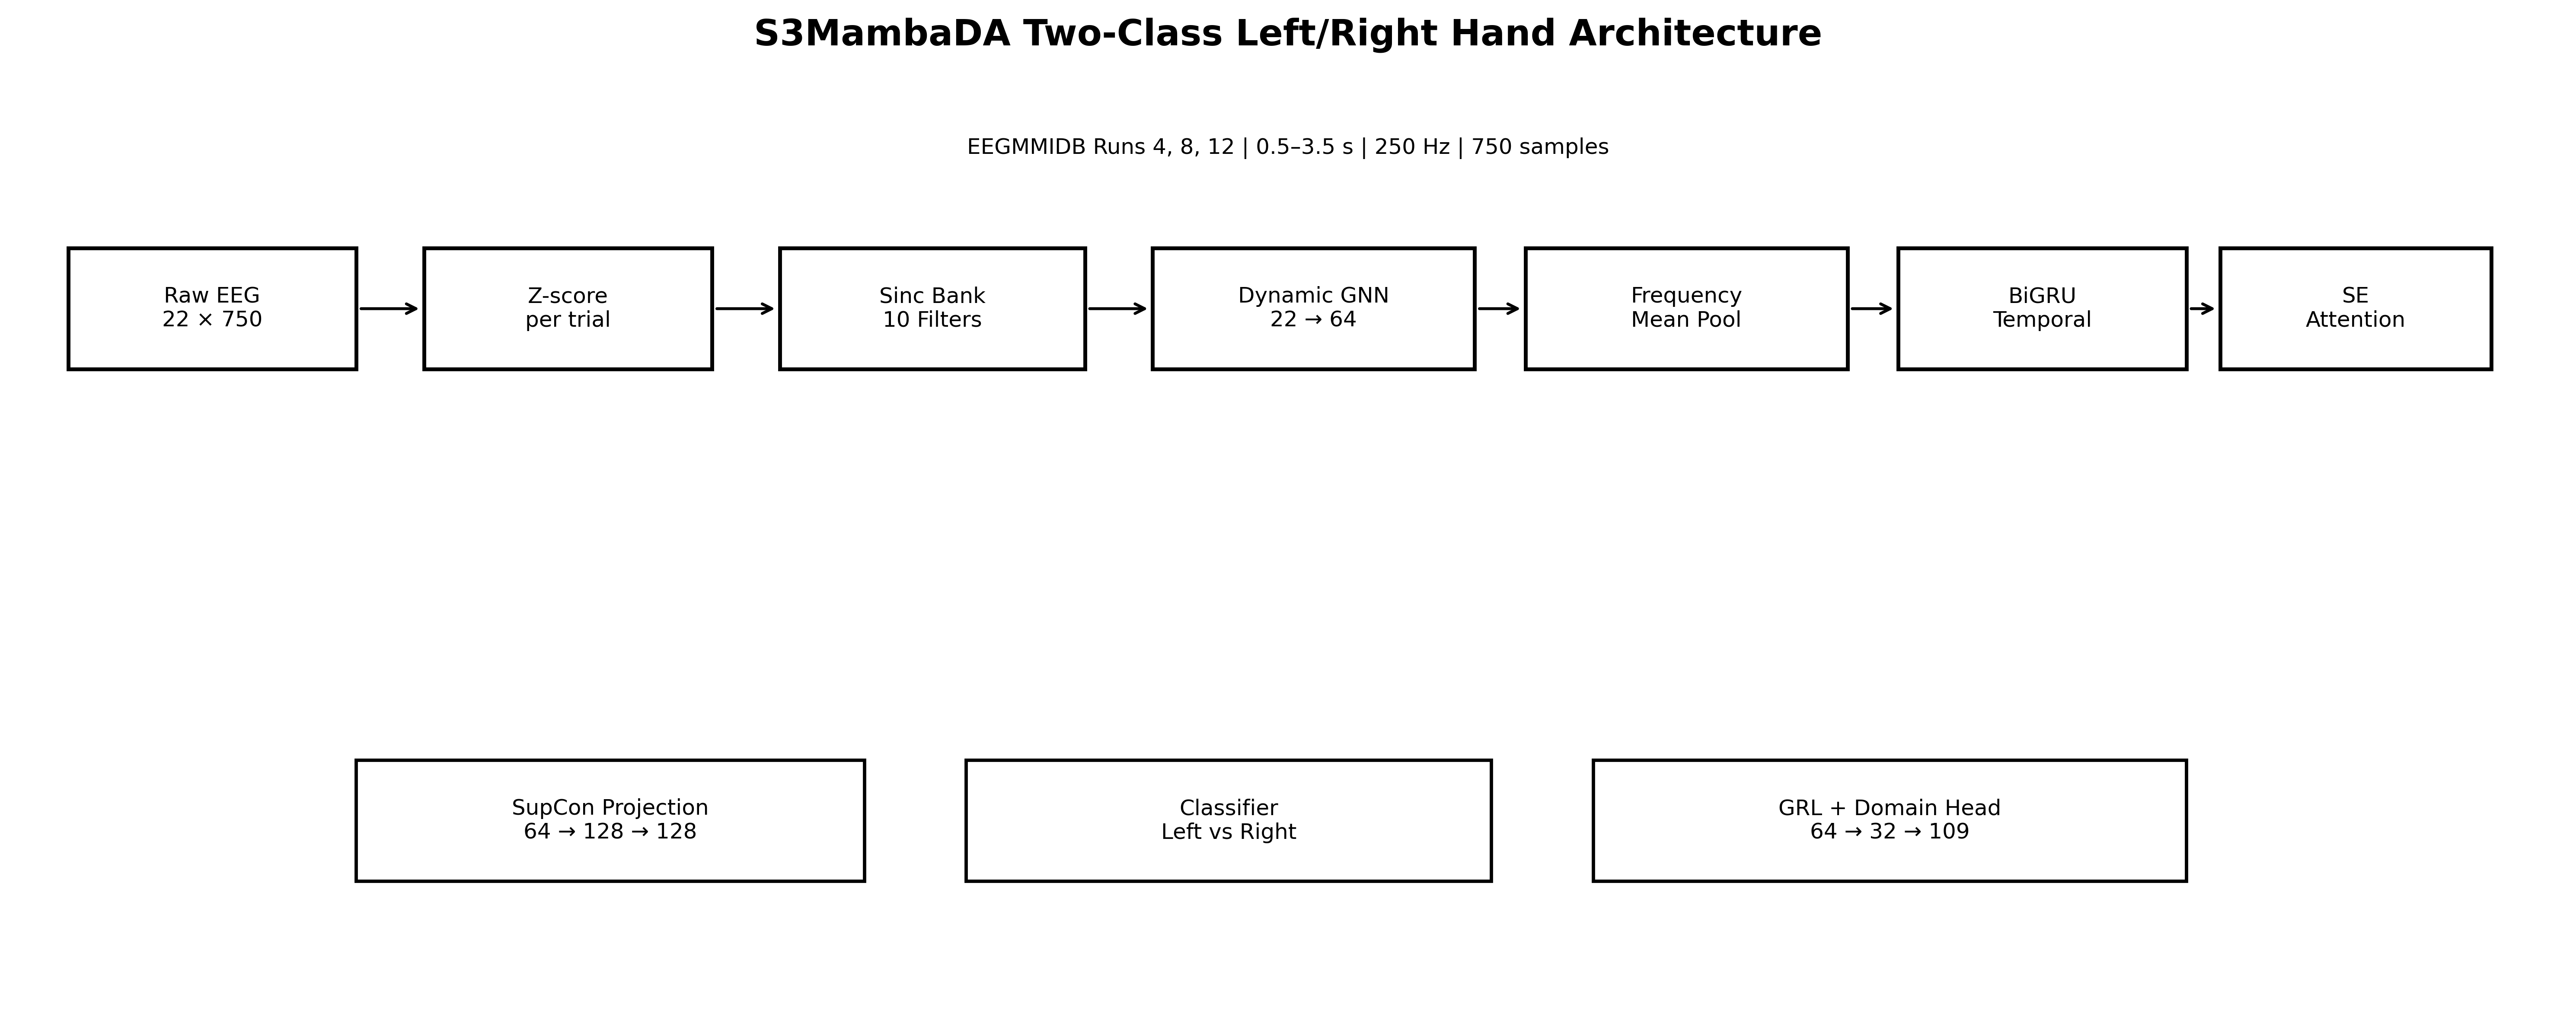

Fig. 1. Overall S3MambaDA spectral-spatial domain-adaptation architecture.
Saved: results_s3mambada_2class/figures/Fig1_Architecture_2Class.png
------------------------------------------------------------------------------------------

FIGURE 2


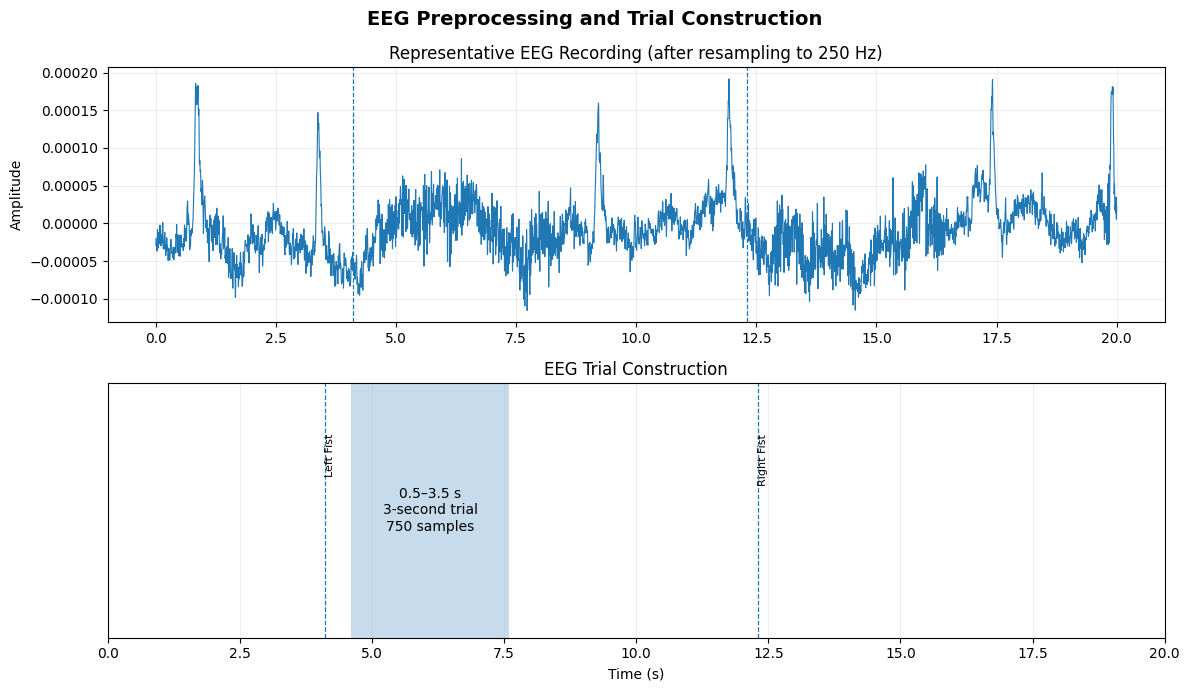

Fig. 2. EEG preprocessing and trial construction: channel selection, 250-Hz resampling, and 0.5–3.5-s motor-imagery windows yielding 750-sample trials.
Saved: results_s3mambada_2class/figures/Fig2_EEG_Preprocessing.png
------------------------------------------------------------------------------------------

FIGURE 3
[SKIP] Fig. 3: trained model object is not available.

FIGURE 4
[SKIP] Fig. 4: trained model object is not available.

FIGURE 5


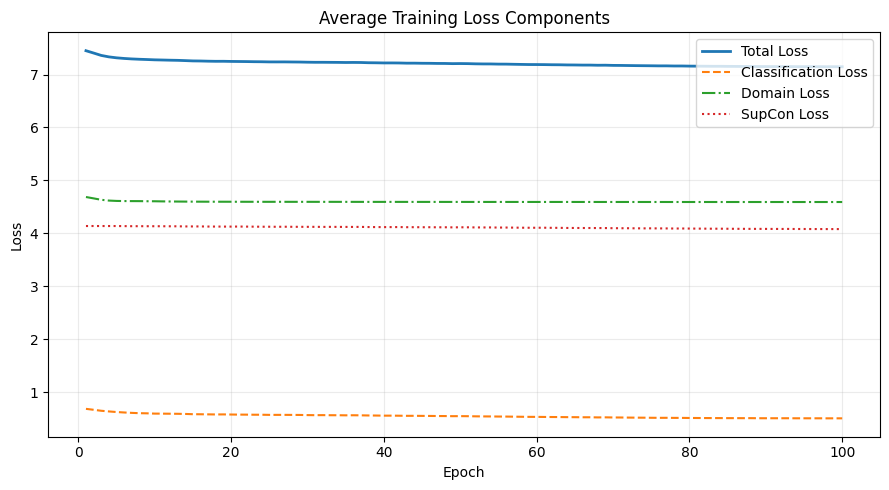

Fig. 5. Training-loss curves averaged across completed target-subject folds.
Saved: results_s3mambada_2class/figures/Fig5_TrainingLoss.png
------------------------------------------------------------------------------------------

FIGURE 6


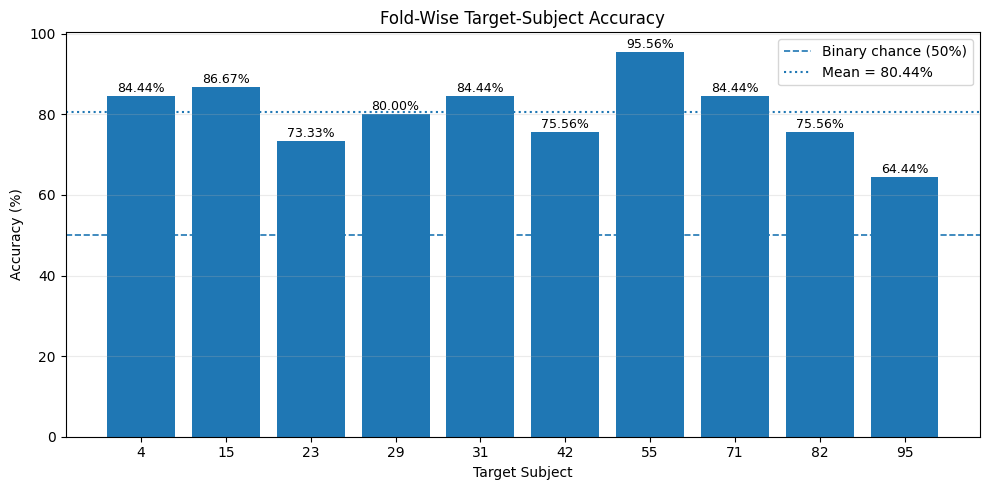

Fig. 6. Fold-wise target-subject accuracy for the Left Fist versus Right Fist experiment.
Saved: results_s3mambada_2class/figures/Fig6_FoldWiseAccuracy.png
------------------------------------------------------------------------------------------

FIGURE 7


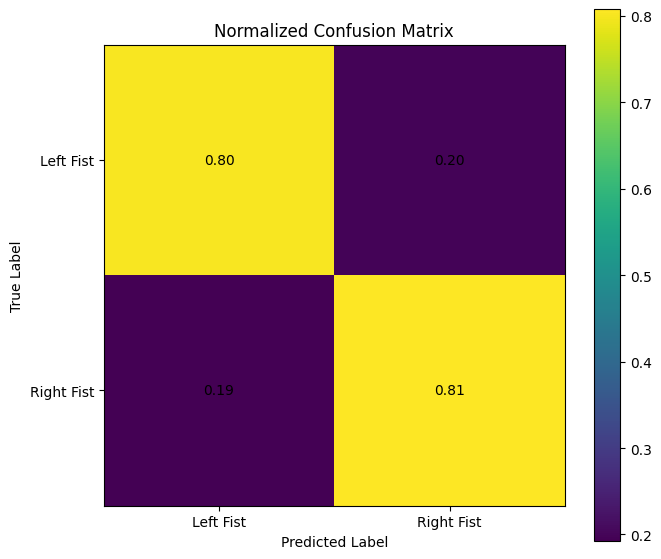

Fig. 7. Normalized confusion matrix for two-class Left Fist versus Right Fist decoding.
Saved: results_s3mambada_2class/figures/Fig7_ConfusionMatrix.png
------------------------------------------------------------------------------------------

FIGURE 8


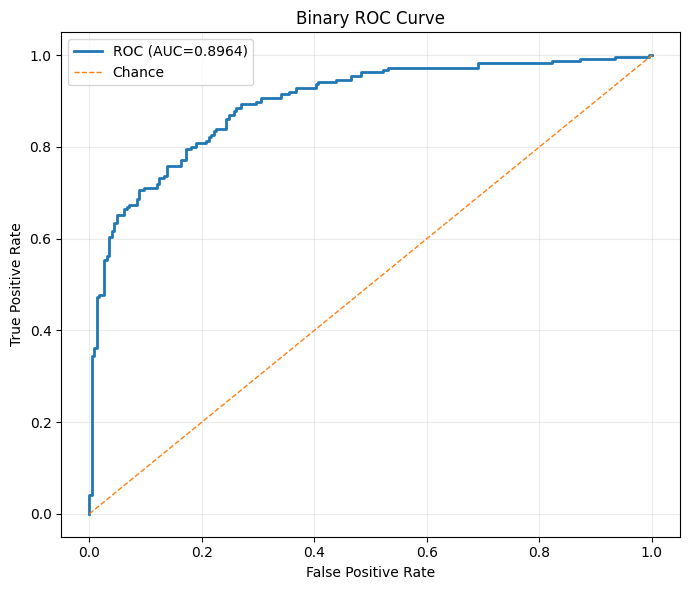

Fig. 8. Receiver operating characteristic for binary Left/Right Hand decoding (AUC = 0.8964).
Saved: results_s3mambada_2class/figures/Fig8_ROC_AUC.png
------------------------------------------------------------------------------------------

FIGURE 9


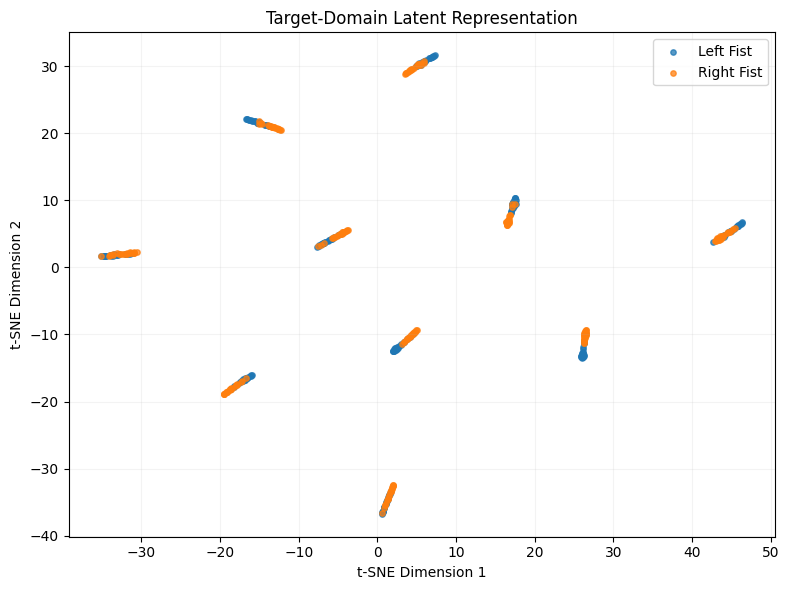

Fig. 9. t-SNE projection of the learned target-domain 128-dimensional supervised-contrastive embeddings.
Saved: results_s3mambada_2class/figures/Fig9_tSNE_Latent.png
------------------------------------------------------------------------------------------

FIGURE 10
[SKIP] Fig. 10: no ablation results available.

FIGURE 11
[SKIP] Fig. 11: no SOTA comparison data available.

FIGURE 12
[SKIP] Fig. 12: no per-subject SOTA data available.

FIGURE 13
[SKIP] Fig. 13: no channel-importance data or trained model available.

PAPER FIGURE AVAILABILITY SUMMARY
Fig. 01 | AVAILABLE       | Fig1_Architecture_2Class.png
Fig. 02 | AVAILABLE       | Fig2_EEG_Preprocessing.png
Fig. 03 | NOT AVAILABLE   | Fig3_Learned_Sinc_Responses.png
Fig. 04 | NOT AVAILABLE   | Fig4_Dynamic_EEG_Graph.png
Fig. 05 | AVAILABLE       | Fig5_TrainingLoss.png
Fig. 06 | AVAILABLE       | Fig6_FoldWiseAccuracy.png
Fig. 07 | AVAILABLE       | Fig7_ConfusionMatrix.png
Fig. 08 | AVAILABLE       | Fig8_ROC_AUC.png
Fig. 09 | AVAI

In [7]:
# ============================================================
# S3MambaDA — COMPLETE PAPER FIGURE DISPLAY MASTER CELL
# ============================================================
#
# RUN THIS CELL AFTER THE FULL TRAINING / EVALUATION CELL.
#
# It automatically displays all available figures:
#
# Fig. 1  Architecture
# Fig. 2  EEG preprocessing / trial construction
# Fig. 3  Learned Sinc filter responses
# Fig. 4  Dynamic EEG graph visualization
# Fig. 5  Training-loss curves
# Fig. 6  Fold-wise target accuracy
# Fig. 7  Confusion matrix
# Fig. 8  ROC/AUC
# Fig. 9  t-SNE/UMAP latent representation
# Fig. 10 Ablation study
# Fig. 11 SOTA comparison
# Fig. 12 Per-subject SOTA comparison
# Fig. 13 Interpretability / channel importance
#
# IMPORTANT:
#   If required data is not available, the corresponding figure
#   is simply skipped.
#
# NO fabricated values are generated.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import os
import math
import json
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Image as IPImage

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

warnings.filterwarnings("ignore")


# ============================================================
# 1. RESULT DIRECTORIES
# ============================================================

# Use the result directory from the experiment if it already
# exists in notebook memory.

if "RESULTS_DIR" in globals():

    RESULTS_ROOT = Path(
        RESULTS_DIR
    )

else:

    RESULTS_ROOT = Path(
        "./results_s3mambada_2class"
    )


FIG_ROOT = (
    RESULTS_ROOT
    / "figures"
)


RESULTS_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


FIG_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


print("=" * 90)

print("S3MambaDA PAPER FIGURE GENERATION + DISPLAY")

print("=" * 90)

print(
    "Results directory:",
    RESULTS_ROOT.resolve()
)

print(
    "Figure directory:",
    FIG_ROOT.resolve()
)

print("=" * 90)


# ============================================================
# 2. TWO-CLASS SETTINGS
# ============================================================

CLASS_NAMES_2 = [
    "Left Fist",
    "Right Fist"
]

NUM_CLASSES_2 = 2


# ============================================================
# 3. DISPLAY HELPER
# ============================================================

def display_figure(
    fig,
    caption,
    filename=None
):

    """
    Saves figure at 400 DPI and displays it inline in Jupyter.
    """

    if filename is None:

        safe_name = (
            caption
            .replace("/", "_")
            .replace(" ", "_")
            .replace(".", "")
            .replace(":", "")
        )

        filename = (
            safe_name
            + ".png"
        )


    output_path = (
        FIG_ROOT
        /
        filename
    )


    fig.savefig(
        output_path,
        dpi=400,
        bbox_inches="tight"
    )


    plt.show()


    print(
        f"{caption}"
    )

    print(
        f"Saved: {output_path}"
    )

    print(
        "-" * 90
    )


def display_existing_image(
    path,
    caption
):

    path = Path(path)


    if not path.exists():

        return False


    display(
        IPImage(
            filename=str(path)
        )
    )


    print(
        caption
    )


    print(
        f"Saved: {path}"
    )


    print(
        "-" * 90
    )


    return True


# ============================================================
# 4. RESULT FILE LOCATOR
# ============================================================

def find_result_file(
    filename
):

    candidates = [

        RESULTS_ROOT
        /
        filename,

        Path(".")
        /
        filename,

        Path("./results_updated_s3mambada")
        /
        filename,

        Path("./results_s3_da")
        /
        filename

    ]


    for candidate in candidates:

        if candidate.exists():

            return candidate


    return None


def find_optional_file(
    *filenames
):

    for filename in filenames:

        result = find_result_file(
            filename
        )


        if result is not None:

            return result


    return None


# ============================================================
# 5. LOAD AVAILABLE EXPERIMENT DATA
# ============================================================

fold_file = find_result_file(
    "fold_metrics.csv"
)

prediction_file = find_result_file(
    "test_predictions.csv"
)

loss_file = find_result_file(
    "epoch_history.csv"
)

embedding_file = find_result_file(
    "test_embeddings.csv"
)

summary_file = find_result_file(
    "summary.json"
)


fold_df = None

prediction_df = None

loss_df = None

embedding_df = None

summary = None


if fold_file is not None:

    try:

        fold_df = pd.read_csv(
            fold_file
        )

    except Exception as e:

        print(
            "[WARNING] Could not read fold_metrics.csv:",
            e
        )


if prediction_file is not None:

    try:

        prediction_df = pd.read_csv(
            prediction_file
        )

    except Exception as e:

        print(
            "[WARNING] Could not read test_predictions.csv:",
            e
        )


if loss_file is not None:

    try:

        loss_df = pd.read_csv(
            loss_file
        )

    except Exception as e:

        print(
            "[WARNING] Could not read epoch_history.csv:",
            e
        )


if embedding_file is not None:

    try:

        embedding_df = pd.read_csv(
            embedding_file
        )

    except Exception as e:

        print(
            "[WARNING] Could not read test_embeddings.csv:",
            e
        )


if summary_file is not None:

    try:

        with open(
            summary_file,
            "r"
        ) as f:

            summary = json.load(
                f
            )

    except Exception as e:

        print(
            "[WARNING] Could not read summary.json:",
            e
        )


# ============================================================
# 6. FIGURE 1
# ARCHITECTURE
# ============================================================

print(
    "\n"
    + "=" * 90
)

print(
    "FIGURE 1"
)

print(
    "=" * 90
)


existing = [

    FIG_ROOT / "Fig1_Architecture_2Class.png",

    FIG_ROOT / "Fig1_Updated_Architecture.png",

    FIG_ROOT / "Fig1_Architecture.png"

]


found = False


for path in existing:

    if display_existing_image(
        path,
        "Fig. 1. Overall S3MambaDA spectral-spatial domain-adaptation architecture."
    ):

        found = True

        break


if not found:

    # Generate architecture figure if it does not already exist.

    fig, ax = plt.subplots(
        figsize=(15, 6)
    )


    ax.set_xlim(
        0,
        15
    )

    ax.set_ylim(
        0,
        7
    )

    ax.axis(
        "off"
    )


    blocks = [

        (
            0.3,
            4.7,
            1.7,
            0.9,
            "Raw EEG\n22 × 750"
        ),

        (
            2.4,
            4.7,
            1.7,
            0.9,
            "Per-trial\nZ-score"
        ),

        (
            4.5,
            4.7,
            1.8,
            0.9,
            "Learnable\nSinc Bank"
        ),

        (
            6.7,
            4.7,
            1.9,
            0.9,
            "Dynamic\nGNN"
        ),

        (
            8.9,
            4.7,
            1.9,
            0.9,
            "Frequency\nMean Pool"
        ),

        (
            11.1,
            4.7,
            1.7,
            0.9,
            "BiGRU"
        ),

        (
            13.0,
            4.7,
            1.6,
            0.9,
            "SE\nAttention"
        )

    ]


    for (
        x,
        y,
        w,
        h,
        txt
    ) in blocks:

        ax.add_patch(

            plt.Rectangle(
                (
                    x,
                    y
                ),
                w,
                h,
                fill=False,
                linewidth=1.6
            )

        )


        ax.text(
            x + w / 2,
            y + h / 2,
            txt,
            ha="center",
            va="center",
            fontsize=9
        )


    for i in range(
        len(blocks) - 1
    ):

        x1 = (
            blocks[i][0]
            +
            blocks[i][2]
        )


        x2 = blocks[
            i + 1
        ][0]


        y = (
            blocks[i][1]
            +
            blocks[i][3] / 2
        )


        ax.annotate(

            "",

            xy=(
                x2,
                y
            ),

            xytext=(
                x1,
                y
            ),

            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.2
            )

        )


    heads = [

        (
            2.0,
            0.9,
            3.0,
            0.9,
            "SupCon Projection\n64 → 128 → 128"
        ),

        (
            5.6,
            0.9,
            3.1,
            0.9,
            "Binary Classifier\nLeft vs Right"
        ),

        (
            9.3,
            0.9,
            3.5,
            0.9,
            "GRL + Domain Head\n64 → 32 → 109"
        )

    ]


    for (
        x,
        y,
        w,
        h,
        txt
    ) in heads:

        ax.add_patch(

            plt.Rectangle(
                (
                    x,
                    y
                ),
                w,
                h,
                fill=False,
                linewidth=1.4
            )

        )


        ax.text(

            x + w / 2,
            y + h / 2,

            txt,

            ha="center",
            va="center",

            fontsize=9

        )


    ax.set_title(
        "S3MambaDA Two-Class Left/Right Hand Architecture",
        fontsize=15,
        fontweight="bold"
    )


    ax.text(

        7.5,
        6.3,

        "EEGMMIDB Runs 4, 8, 12 | "
        "0.5–3.5 s | "
        "250 Hz | "
        "750 samples",

        ha="center",

        fontsize=9

    )


    display_figure(

        fig,

        "Fig. 1. Overall S3MambaDA spectral-spatial domain-adaptation architecture.",

        "Fig1_Architecture_2Class.png"

    )


# ============================================================
# 7. FIGURE 2
# EEG PREPROCESSING / TRIAL CONSTRUCTION
# ============================================================

print(
    "\n"
    + "=" * 90
)

print(
    "FIGURE 2"
)

print(
    "=" * 90
)


# ------------------------------------------------------------
# Try to locate a representative subject EDF.
# ------------------------------------------------------------

data_root = Path(
    DATA_DIR if "DATA_DIR" in globals()
    else "./eegmmidb"
)


representative_edf = None


preferred_subjects = [

    4,
    15,
    23,
    29,
    31

]


for subject in preferred_subjects:

    candidate = (
        data_root
        /
        f"S{subject:03d}"
        /
        f"S{subject:03d}R04.edf"
    )


    if candidate.exists():

        representative_edf = candidate

        break


# ------------------------------------------------------------
# Generate only when raw EDF exists.
# ------------------------------------------------------------

if representative_edf is not None:

    try:

        raw = mne.io.read_raw_edf(
            representative_edf,
            preload=True,
            verbose=False
        )


        original_sfreq = raw.info[
            "sfreq"
        ]


        original_duration = (
            raw.times[-1]
            if len(raw.times)
            else 0
        )


        # Copy for plotting / preprocessing.

        raw_plot = raw.copy()

        raw_plot.pick(
            raw_plot.ch_names[
                :min(
                    N_CHANNELS
                    if "N_CHANNELS" in globals()
                    else 22,
                    len(
                        raw_plot.ch_names
                    )
                )
            ]
        )


        raw_plot.resample(
            250.0
        )


        events, event_dict = \
            mne.events_from_annotations(
                raw_plot,
                verbose=False
            )


        # Find T1/T2.

        normalized = {}

        for key, value in event_dict.items():

            normalized[
                str(key)
                .strip()
                .upper()
            ] = value


        t1_id = normalized.get(
            "T1"
        )

        t2_id = normalized.get(
            "T2"
        )


        event_positions = []


        event_labels = []


        if t1_id is not None:

            t1_events = events[
                events[:, 2] == t1_id
            ]

            event_positions.extend(
                t1_events[:, 0]
                / 250.0
            )

            event_labels.extend(
                [
                    "T1"
                ] * len(t1_events)
            )


        if t2_id is not None:

            t2_events = events[
                events[:, 2] == t2_id
            ]

            event_positions.extend(
                t2_events[:, 0]
                / 250.0
            )

            event_labels.extend(
                [
                    "T2"
                ] * len(t2_events)
            )


        # Use the first EEG channel as representative trace.

        channel_data = raw_plot.get_data(
            picks=[0]
        )[0]


        times = raw_plot.times


        fig, axes = plt.subplots(
            2,
            1,
            figsize=(12, 7),
            sharex=False
        )


        # --------------------------------------------------------
        # Raw signal
        # --------------------------------------------------------

        max_plot_time = min(
            20.0,
            times[-1]
        )


        mask = (
            times
            <=
            max_plot_time
        )


        axes[0].plot(
            times[mask],
            channel_data[mask],
            linewidth=0.8
        )


        axes[0].set_title(
            "Representative EEG Recording "
            "(after resampling to 250 Hz)"
        )


        axes[0].set_ylabel(
            "Amplitude"
        )


        axes[0].grid(
            True,
            alpha=0.2
        )


        # --------------------------------------------------------
        # Trial construction
        # --------------------------------------------------------

        if len(event_positions) > 0:

            # Show first event in the displayed interval.

            for pos, label in zip(
                event_positions,
                event_labels
            ):

                if pos > max_plot_time:

                    continue


                if label == "T1":

                    class_text = \
                        "Left Fist"

                else:

                    class_text = \
                        "Right Fist"


                axes[0].axvline(
                    pos,
                    linestyle="--",
                    linewidth=0.9
                )


                axes[1].axvline(
                    pos,
                    linestyle="--",
                    linewidth=0.9
                )


                axes[1].text(
                    pos,
                    0.8,
                    class_text,
                    rotation=90,
                    fontsize=8,
                    va="top"
                )


        # --------------------------------------------------------
        # Trial window illustration
        # --------------------------------------------------------

        if len(event_positions) > 0:

            event0 = event_positions[0]

            start = event0 + 0.5

            end = event0 + 3.5


            axes[1].axvspan(
                start,
                end,
                alpha=0.25
            )


            axes[1].text(
                (start + end) / 2,
                0.5,
                "0.5–3.5 s\n3-second trial\n750 samples",
                ha="center",
                va="center",
                fontsize=10
            )


        axes[1].set_xlim(
            0,
            max_plot_time
        )


        axes[1].set_ylim(
            0,
            1
        )


        axes[1].set_yticks([])


        axes[1].set_xlabel(
            "Time (s)"
        )


        axes[1].set_title(
            "EEG Trial Construction"
        )


        axes[1].grid(
            axis="x",
            alpha=0.2
        )


        fig.suptitle(
            "EEG Preprocessing and Trial Construction",
            fontsize=14,
            fontweight="bold"
        )


        fig.tight_layout()


        display_figure(

            fig,

            "Fig. 2. EEG preprocessing and trial construction: channel selection, 250-Hz resampling, and 0.5–3.5-s motor-imagery windows yielding 750-sample trials.",

            "Fig2_EEG_Preprocessing.png"

        )


    except Exception as e:

        print(
            "[SKIP] Fig. 2 could not be generated:",
            e
        )


else:

    print(
        "[SKIP] Fig. 2: representative EDF file not found."
    )


# ============================================================
# 8. FIGURE 3
# LEARNED SINC FILTER RESPONSES
# ============================================================

print(
    "\n"
    + "=" * 90
)

print(
    "FIGURE 3"
)

print(
    "=" * 90
)


# ------------------------------------------------------------
# Need trained model.
# Search common notebook variables.
# ------------------------------------------------------------

candidate_model = None


if "model" in globals():

    candidate_model = model


elif "trained_model" in globals():

    candidate_model = trained_model


elif "best_model" in globals():

    candidate_model = best_model


if candidate_model is not None:

    try:

        if hasattr(
            candidate_model,
            "sinc_filter"
        ):

            sinc = \
                candidate_model.sinc_filter


            f1 = (
                sinc.f1
                .detach()
                .cpu()
                .numpy()
            )


            f2 = (
                sinc.f2
                .detach()
                .cpu()
                .numpy()
            )


            sample_rate = \
                float(
                    getattr(
                        sinc,
                        "sample_rate",
                        250
                    )
                )


            kernel_size = \
                int(
                    getattr(
                        sinc,
                        "kernel_size",
                        81
                    )
                )


            n = np.arange(
                -(kernel_size // 2),
                (kernel_size // 2) + 1
            )


            t = n / sample_rate


            fig, ax = plt.subplots(
                figsize=(10, 6)
            )


            for i in range(
                len(f1)
            ):

                low = float(
                    f1[i]
                )

                high = float(
                    f2[i]
                )


                low_scaled = \
                    low / sample_rate


                high_scaled = \
                    high / sample_rate


                w = (

                    2
                    *
                    high_scaled
                    *
                    np.sinc(
                        2
                        *
                        high_scaled
                        *
                        n
                    )

                    -

                    2
                    *
                    low_scaled
                    *
                    np.sinc(
                        2
                        *
                        low_scaled
                        *
                        n
                    )

                )


                # Frequency response.

                response = np.abs(
                    np.fft.rfft(
                        w,
                        n=2048
                    )
                )


                freqs = np.fft.rfftfreq(
                    2048,
                    d=1.0/sample_rate
                )


                response = (
                    response
                    /
                    (
                        response.max()
                        +
                        1e-12
                    )
                )


                ax.plot(
                    freqs,
                    response,
                    linewidth=1.2
                )


            ax.set_xlim(
                0,
                min(
                    60,
                    sample_rate / 2
                )
            )


            ax.set_xlabel(
                "Frequency (Hz)"
            )


            ax.set_ylabel(
                "Normalized magnitude"
            )


            ax.set_title(
                "Learned Sinc Filter-Bank Responses"
            )


            ax.grid(
                True,
                alpha=0.25
            )


            fig.tight_layout()


            display_figure(

                fig,

                "Fig. 3. Learned frequency responses of the ten Sinc filters after model training.",

                "Fig3_Learned_Sinc_Responses.png"

            )


        else:

            print(
                "[SKIP] Fig. 3: model has no sinc_filter module."
            )


    except Exception as e:

        print(
            "[SKIP] Fig. 3:",
            e
        )


else:

    # If a previously generated image exists, display it.

    existing = [

        FIG_ROOT
        / "Fig3_Learned_Sinc_Responses.png",

        FIG_ROOT
        / "Fig3_SincFilterResponses.png",

        Path("./Fig3_SincFilterResponses.png")

    ]


    shown = False


    for path in existing:

        if display_existing_image(

            path,

            "Fig. 3. Learned Sinc filter responses."

        ):

            shown = True

            break


    if not shown:

        print(
            "[SKIP] Fig. 3: trained model object is not available."
        )


# ============================================================
# 9. FIGURE 4
# DYNAMIC EEG GRAPH
# ============================================================

print(
    "\n"
    + "=" * 90
)

print(
    "FIGURE 4"
)

print(
    "=" * 90
)


if candidate_model is not None:

    try:

        # --------------------------------------------------------
        # Locate DGNN module
        # --------------------------------------------------------

        if not hasattr(
            candidate_model,
            "dgnn"
        ):

            raise RuntimeError(
                "Model has no DGNN."
            )


        # --------------------------------------------------------
        # Obtain one example EEG trial.
        # --------------------------------------------------------

        example_dataset = None


        if "test_dataset" in globals():

            example_dataset = \
                test_dataset


        elif "train_dataset" in globals():

            example_dataset = \
                train_dataset


        else:

            # Try a small target subject.

            example_dataset = \
                EEGMMIDB_Dataset(

                    DATA_DIR,

                    [
                        4
                    ]

                )


        if len(
            example_dataset
        ) == 0:

            raise RuntimeError(
                "No EEG trial available."
            )


        x, _, _ = \
            example_dataset[0]


        x = x.unsqueeze(
            0
        ).to(
            DEVICE
        )


        candidate_model.eval()


        with torch.no_grad():

            f_out = \
                candidate_model.sinc_filter(
                    x
                )


            # Replicate the graph construction in DGNN.

            B, F, C, T = \
                f_out.shape


            x_flat = (
                f_out
                .mean(
                    dim=-1
                )
                .transpose(
                    1,
                    2
                )
            )


            Q = candidate_model.dgnn.W_Q(
                x_flat
            )


            K = candidate_model.dgnn.W_K(
                x_flat
            )


            A = torch.matmul(
                Q,
                K.transpose(
                    -2,
                    -1
                )
            ) / math.sqrt(
                candidate_model.dgnn.num_filters
            )


            A = F.softmax(
                A,
                dim=-1
            )


            adjacency = \
                A[0].detach().cpu().numpy()


        # --------------------------------------------------------
        # Draw dynamic graph as adjacency heatmap.
        # --------------------------------------------------------

        fig, ax = plt.subplots(
            figsize=(8, 7)
        )


        im = ax.imshow(
            adjacency,
            interpolation="nearest"
        )


        ax.set_title(
            "Dynamic EEG Channel Adjacency"
        )


        ax.set_xlabel(
            "EEG Channel"
        )


        ax.set_ylabel(
            "EEG Channel"
        )


        labels = [
            str(i + 1)
            for i in range(
                adjacency.shape[0]
            )
        ]


        ax.set_xticks(
            range(
                adjacency.shape[0]
            ),
            labels,
            rotation=90,
            fontsize=7
        )


        ax.set_yticks(
            range(
                adjacency.shape[0]
            ),
            labels,
            fontsize=7
        )


        fig.colorbar(
            im,
            ax=ax,
            fraction=0.046,
            pad=0.04,
            label="Edge weight"
        )


        fig.tight_layout()


        display_figure(

            fig,

            "Fig. 4. Dynamic EEG graph visualization showing the learned channel-to-channel adjacency matrix.",

            "Fig4_Dynamic_EEG_Graph.png"

        )


    except Exception as e:

        print(
            "[SKIP] Fig. 4:",
            e
        )


else:

    print(
        "[SKIP] Fig. 4: trained model object is not available."
    )


# ============================================================
# 10. FIGURE 5
# TRAINING LOSS
# ============================================================

print(
    "\n"
    + "=" * 90
)

print(
    "FIGURE 5"
)

print(
    "=" * 90
)


if loss_df is not None and not loss_df.empty:

    required_columns = [

        "epoch",

        "loss_total",

        "loss_cls",

        "loss_domain",

        "loss_supcon"

    ]


    if all(
        c in loss_df.columns
        for c in required_columns
    ):

        g = (
            loss_df
            .groupby(
                "epoch"
            )
            .mean(
                numeric_only=True
            )
        )


        fig, ax = plt.subplots(
            figsize=(9, 5)
        )


        ax.plot(

            g.index,

            g["loss_total"],

            linewidth=2,

            label="Total Loss"

        )


        ax.plot(

            g.index,

            g["loss_cls"],

            linestyle="--",

            label="Classification Loss"

        )


        ax.plot(

            g.index,

            g["loss_domain"],

            linestyle="-.",

            label="Domain Loss"

        )


        ax.plot(

            g.index,

            g["loss_supcon"],

            linestyle=":",

            label="SupCon Loss"

        )


        ax.set_xlabel(
            "Epoch"
        )


        ax.set_ylabel(
            "Loss"
        )


        ax.set_title(
            "Average Training Loss Components"
        )


        ax.grid(
            True,
            alpha=0.25
        )


        ax.legend()


        fig.tight_layout()


        display_figure(

            fig,

            "Fig. 5. Training-loss curves averaged across completed target-subject folds.",

            "Fig5_TrainingLoss.png"

        )


    else:

        print(
            "[SKIP] Fig. 5: required loss columns are missing."
        )


else:

    print(
        "[SKIP] Fig. 5: epoch_history.csv not available."
    )


# ============================================================
# 11. FIGURE 6
# FOLD-WISE TARGET ACCURACY
# ============================================================

print(
    "\n"
    + "=" * 90
)

print(
    "FIGURE 6"
)

print(
    "=" * 90
)


if (
    fold_df is not None
    and not fold_df.empty
    and "accuracy" in fold_df.columns
    and "target_subject" in fold_df.columns
):

    acc_values = (
        fold_df[
            "accuracy"
        ]
        * 100
    )


    labels = [

        str(
            int(
                subject
            )
        )

        for subject
        in fold_df[
            "target_subject"
        ]

    ]


    fig, ax = plt.subplots(
        figsize=(10, 5)
    )


    ax.bar(
        labels,
        acc_values
    )


    ax.axhline(

        50,

        linestyle="--",

        linewidth=1.2,

        label="Binary chance (50%)"

    )


    ax.axhline(

        acc_values.mean(),

        linestyle=":",

        linewidth=1.5,

        label=(

            f"Mean = "
            f"{acc_values.mean():.2f}%"

        )

    )


    for i, value in enumerate(
        acc_values
    ):

        ax.text(

            i,

            value + 1.0,

            f"{value:.2f}%",

            ha="center",

            fontsize=9

        )


    ax.set_xlabel(
        "Target Subject"
    )


    ax.set_ylabel(
        "Accuracy (%)"
    )


    ax.set_title(
        "Fold-Wise Target-Subject Accuracy"
    )


    ax.grid(
        axis="y",
        alpha=0.25
    )


    ax.legend()


    fig.tight_layout()


    display_figure(

        fig,

        "Fig. 6. Fold-wise target-subject accuracy for the Left Fist versus Right Fist experiment.",

        "Fig6_FoldWiseAccuracy.png"

    )


else:

    print(
        "[SKIP] Fig. 6: fold metrics unavailable."
    )


# ============================================================
# 12. FIGURE 7
# CONFUSION MATRIX
# ============================================================

print(
    "\n"
    + "=" * 90
)

print(
    "FIGURE 7"
)

print(
    "=" * 90
)


if (
    prediction_df is not None
    and not prediction_df.empty
):

    if (
        "true_label" in prediction_df.columns
        and
        "pred_label" in prediction_df.columns
    ):

        cm = confusion_matrix(

            prediction_df[
                "true_label"
            ],

            prediction_df[
                "pred_label"
            ],

            labels=[
                0,
                1
            ]

        )


        row_sum = cm.sum(
            axis=1,
            keepdims=True
        )


        cm_norm = np.divide(

            cm,

            row_sum,

            out=np.zeros_like(
                cm,
                dtype=float
            ),

            where=(
                row_sum != 0
            )

        )


        fig, ax = plt.subplots(
            figsize=(7, 6)
        )


        im = ax.imshow(
            cm_norm
        )


        ax.set_xticks(

            [
                0,
                1
            ],

            CLASS_NAMES_2

        )


        ax.set_yticks(

            [
                0,
                1
            ],

            CLASS_NAMES_2

        )


        ax.set_xlabel(
            "Predicted Label"
        )


        ax.set_ylabel(
            "True Label"
        )


        ax.set_title(
            "Normalized Confusion Matrix"
        )


        for i in range(2):

            for j in range(2):

                ax.text(

                    j,

                    i,

                    f"{cm_norm[i,j]:.2f}",

                    ha="center",

                    va="center"

                )


        fig.colorbar(
            im,
            ax=ax
        )


        fig.tight_layout()


        display_figure(

            fig,

            "Fig. 7. Normalized confusion matrix for two-class Left Fist versus Right Fist decoding.",

            "Fig7_ConfusionMatrix.png"

        )


    else:

        print(
            "[SKIP] Fig. 7: prediction columns missing."
        )


else:

    print(
        "[SKIP] Fig. 7: test predictions unavailable."
    )


# ============================================================
# 13. FIGURE 8
# ROC / AUC
# ============================================================

print(
    "\n"
    + "=" * 90
)

print(
    "FIGURE 8"
)

print(
    "=" * 90
)


if (
    prediction_df is not None
    and not prediction_df.empty
):

    required = [

        "true_label",

        "prob_right"

    ]


    if all(
        c in prediction_df.columns
        for c in required
    ):

        y_true = prediction_df[
            "true_label"
        ].to_numpy()


        y_score = prediction_df[
            "prob_right"
        ].to_numpy()


        if len(
            np.unique(
                y_true
            )
        ) == 2:

            fpr, tpr, _ = \
                roc_curve(

                    y_true,

                    y_score

                )


            roc_auc = auc(
                fpr,
                tpr
            )


            fig, ax = plt.subplots(
                figsize=(7, 6)
            )


            ax.plot(

                fpr,

                tpr,

                linewidth=2,

                label=(

                    f"ROC "
                    f"(AUC={roc_auc:.4f})"

                )

            )


            ax.plot(

                [
                    0,
                    1
                ],

                [
                    0,
                    1
                ],

                linestyle="--",

                linewidth=1,

                label="Chance"

            )


            ax.set_xlabel(
                "False Positive Rate"
            )


            ax.set_ylabel(
                "True Positive Rate"
            )


            ax.set_title(
                "Binary ROC Curve"
            )


            ax.grid(
                True,
                alpha=0.25
            )


            ax.legend()


            fig.tight_layout()


            display_figure(

                fig,

                f"Fig. 8. Receiver operating characteristic for binary Left/Right Hand decoding (AUC = {roc_auc:.4f}).",

                "Fig8_ROC_AUC.png"

            )


        else:

            print(
                "[SKIP] Fig. 8: only one class is present in the prediction file."
            )


    else:

        print(
            "[SKIP] Fig. 8: probability columns are missing."
        )


else:

    print(
        "[SKIP] Fig. 8: prediction file unavailable."
    )


# ============================================================
# 14. FIGURE 9
# t-SNE / UMAP LATENT REPRESENTATION
# ============================================================

print(
    "\n"
    + "=" * 90
)

print(
    "FIGURE 9"
)

print(
    "=" * 90
)


if (
    embedding_df is not None
    and not embedding_df.empty
):

    z_columns = [

        c

        for c in embedding_df.columns

        if c.startswith(
            "z_"
        )

    ]


    if len(
        z_columns
    ) >= 2:

        X = embedding_df[
            z_columns
        ].to_numpy()


        y = embedding_df[
            "true_label"
        ].to_numpy()


        if len(X) >= 10:

            try:

                from sklearn.manifold import TSNE


                perplexity = min(

                    30,

                    max(

                        5,

                        (len(X)-1)//3

                    )

                )


                Z = TSNE(

                    n_components=2,

                    perplexity=
                        perplexity,

                    init="pca",

                    learning_rate="auto",

                    random_state=42

                ).fit_transform(
                    X
                )


                fig, ax = plt.subplots(
                    figsize=(8, 6)
                )


                for c in range(2):

                    mask = (
                        y == c
                    )


                    if mask.sum() == 0:

                        continue


                    ax.scatter(

                        Z[
                            mask,
                            0
                        ],

                        Z[
                            mask,
                            1
                        ],

                        s=15,

                        alpha=0.75,

                        label=
                            CLASS_NAMES_2[c]

                    )


                ax.set_xlabel(
                    "t-SNE Dimension 1"
                )


                ax.set_ylabel(
                    "t-SNE Dimension 2"
                )


                ax.set_title(
                    "Target-Domain Latent Representation"
                )


                ax.grid(
                    True,
                    alpha=0.15
                )


                ax.legend()


                fig.tight_layout()


                display_figure(

                    fig,

                    "Fig. 9. t-SNE projection of the learned target-domain 128-dimensional supervised-contrastive embeddings.",

                    "Fig9_tSNE_Latent.png"

                )


            except Exception as e:

                print(
                    "[SKIP] Fig. 9:",
                    e
                )


        else:

            print(
                "[SKIP] Fig. 9: insufficient embeddings."
            )


    else:

        print(
            "[SKIP] Fig. 9: latent embedding columns unavailable."
        )


else:

    print(
        "[SKIP] Fig. 9: test embeddings unavailable."
    )


# ============================================================
# 15. FIGURE 10
# ABLATION STUDY
# ============================================================

print(
    "\n"
    + "=" * 90
)

print(
    "FIGURE 10"
)

print(
    "=" * 90
)


ablation_file = find_optional_file(

    "ablation_results.csv",

    "ablation_metrics.csv",

    "ablation_summary.csv"

)


if ablation_file is not None:

    try:

        ablation_df = pd.read_csv(
            ablation_file
        )


        # Find likely condition and accuracy columns.

        condition_col = None

        accuracy_col = None


        for c in [
            "condition",
            "model",
            "variant",
            "ablation",
            "name"
        ]:

            if c in ablation_df.columns:

                condition_col = c

                break


        for c in [
            "accuracy",
            "mean_accuracy",
            "acc",
            "test_accuracy"
        ]:

            if c in ablation_df.columns:

                accuracy_col = c

                break


        if (
            condition_col is not None
            and accuracy_col is not None
        ):

            values = (
                ablation_df[
                    accuracy_col
                ].astype(
                    float
                )
            )


            if values.max() <= 1.0:

                values = values * 100


            fig, ax = plt.subplots(
                figsize=(10, 5)
            )


            x = np.arange(
                len(
                    ablation_df
                )
            )


            ax.bar(
                x,
                values
            )


            ax.set_xticks(
                x,
                ablation_df[
                    condition_col
                ].astype(
                    str
                ),
                rotation=25,
                ha="right"
            )


            ax.set_ylabel(
                "Accuracy (%)"
            )


            ax.set_title(
                "Ablation Study"
            )


            ax.grid(
                axis="y",
                alpha=0.25
            )


            fig.tight_layout()


            display_figure(

                fig,

                "Fig. 10. Ablation study showing the effect of removing individual components from the proposed architecture.",

                "Fig10_AblationStudy.png"

            )


        else:

            print(
                "[SKIP] Fig. 10: required ablation columns not found."
            )


    except Exception as e:

        print(
            "[SKIP] Fig. 10:",
            e
        )


else:

    print(
        "[SKIP] Fig. 10: no ablation results available."
    )


# ============================================================
# 16. FIGURE 11
# SOTA COMPARISON
# ============================================================

print(
    "\n"
    + "=" * 90
)

print(
    "FIGURE 11"
)

print(
    "=" * 90
)


sota_file = find_optional_file(

    "sota_comparison.csv",

    "SOTA_comparison.csv",

    "baseline_comparison.csv",

    "model_comparison.csv"

)


if sota_file is not None:

    try:

        sota_df = pd.read_csv(
            sota_file
        )


        method_col = None

        accuracy_col = None


        for c in [
            "method",
            "model",
            "approach",
            "name"
        ]:

            if c in sota_df.columns:

                method_col = c

                break


        for c in [
            "accuracy",
            "mean_accuracy",
            "acc"
        ]:

            if c in sota_df.columns:

                accuracy_col = c

                break


        if (
            method_col is not None
            and accuracy_col is not None
        ):

            values = sota_df[
                accuracy_col
            ].astype(
                float
            )


            if values.max() <= 1.0:

                values = values * 100


            fig, ax = plt.subplots(
                figsize=(11, 5)
            )


            x = np.arange(
                len(
                    sota_df
                )
            )


            ax.bar(
                x,
                values
            )


            ax.set_xticks(

                x,

                sota_df[
                    method_col
                ].astype(
                    str
                ),

                rotation=30,

                ha="right"

            )


            ax.set_ylabel(
                "Accuracy (%)"
            )


            ax.set_title(
                "Comparison with State-of-the-Art Methods"
            )


            ax.grid(
                axis="y",
                alpha=0.25
            )


            fig.tight_layout()


            display_figure(

                fig,

                "Fig. 11. Accuracy comparison between the proposed model and available state-of-the-art baselines.",

                "Fig11_SOTA_Comparison.png"

            )


        else:

            print(
                "[SKIP] Fig. 11: expected SOTA columns not found."
            )


    except Exception as e:

        print(
            "[SKIP] Fig. 11:",
            e
        )


else:

    print(
        "[SKIP] Fig. 11: no SOTA comparison data available."
    )


# ============================================================
# 17. FIGURE 12
# PER-SUBJECT SOTA COMPARISON
# ============================================================

print(
    "\n"
    + "=" * 90
)

print(
    "FIGURE 12"
)

print(
    "=" * 90
)


per_subject_file = find_optional_file(

    "per_subject_sota.csv",

    "per_subject_comparison.csv",

    "subject_sota.csv"

)


if per_subject_file is not None:

    try:

        ps_df = pd.read_csv(
            per_subject_file
        )


        subject_col = None


        for c in [
            "subject",
            "target_subject",
            "subject_id"
        ]:

            if c in ps_df.columns:

                subject_col = c

                break


        # Identify comparison columns.

        comparison_columns = []


        preferred_prefixes = [
            "S3MambaDA",
            "Proposed",
            "EEGNet",
            "DeepConvNet",
            "ShallowConvNet"
        ]


        for prefix in preferred_prefixes:

            matches = [

                c

                for c in ps_df.columns

                if prefix.lower()
                in c.lower()

            ]


            comparison_columns.extend(
                matches
            )


        # If no known names, infer all numeric columns except subject.

        if len(
            comparison_columns
        ) == 0:

            comparison_columns = [

                c

                for c in ps_df.columns

                if c != subject_col
                and
                pd.api.types.is_numeric_dtype(
                    ps_df[c]
                )

            ]


        comparison_columns = list(
            dict.fromkeys(
                comparison_columns
            )
        )


        if (
            subject_col is not None
            and len(
                comparison_columns
            ) >= 2
        ):

            fig, ax = plt.subplots(
                figsize=(12, 6)
            )


            x = np.arange(
                len(
                    ps_df
                )
            )


            width = (
                0.8
                /
                len(
                    comparison_columns
                )
            )


            for i, col in enumerate(
                comparison_columns
            ):

                values = ps_df[
                    col
                ].astype(
                    float
                )


                if values.max() <= 1.0:

                    values = values * 100


                ax.bar(

                    x
                    +
                    (
                        i
                        -
                        len(
                            comparison_columns
                        ) / 2
                        + 0.5
                    )
                    * width,

                    values,

                    width,

                    label=str(
                        col
                    )

                )


            ax.set_xticks(
                x,
                ps_df[
                    subject_col
                ].astype(
                    str
                )
            )


            ax.set_xlabel(
                "Target Subject"
            )


            ax.set_ylabel(
                "Accuracy (%)"
            )


            ax.set_title(
                "Per-Subject Comparison with Baselines"
            )


            ax.legend(
                fontsize=8
            )


            ax.grid(
                axis="y",
                alpha=0.25
            )


            fig.tight_layout()


            display_figure(

                fig,

                "Fig. 12. Per-subject accuracy comparison between the proposed method and available baseline/SOTA methods.",

                "Fig12_PerSubject_SOTA.png"

            )


        else:

            print(
                "[SKIP] Fig. 12: incompatible per-subject SOTA file."
            )


    except Exception as e:

        print(
            "[SKIP] Fig. 12:",
            e
        )


else:

    print(
        "[SKIP] Fig. 12: no per-subject SOTA data available."
    )


# ============================================================
# 18. FIGURE 13
# INTERPRETABILITY / CHANNEL IMPORTANCE
# ============================================================

print(
    "\n"
    + "=" * 90
)

print(
    "FIGURE 13"
)

print(
    "=" * 90
)


# First preference: precomputed channel importance CSV.

importance_file = find_optional_file(

    "channel_importance.csv",

    "channel_importance_scores.csv",

    "interpretability.csv",

    "channel_scores.csv"

)


if importance_file is not None:

    try:

        imp_df = pd.read_csv(
            importance_file
        )


        channel_col = None

        score_col = None


        for c in [
            "channel",
            "channel_id",
            "electrode",
            "name"
        ]:

            if c in imp_df.columns:

                channel_col = c

                break


        for c in [
            "importance",
            "score",
            "importance_score",
            "mean_importance"
        ]:

            if c in imp_df.columns:

                score_col = c

                break


        if (
            channel_col is not None
            and score_col is not None
        ):

            values = imp_df[
                score_col
            ].astype(
                float
            )


            order = np.argsort(
                values.to_numpy()
            )


            fig, ax = plt.subplots(
                figsize=(9, 7)
            )


            ax.barh(

                np.arange(
                    len(
                        imp_df
                    )
                ),

                values.iloc[
                    order
                ]

            )


            ax.set_yticks(

                np.arange(
                    len(
                        imp_df
                    )
                ),

                imp_df[
                    channel_col
                ].iloc[
                    order
                ].astype(
                    str
                )

            )


            ax.set_xlabel(
                "Importance"
            )


            ax.set_ylabel(
                "EEG Channel"
            )


            ax.set_title(
                "Channel Importance"
            )


            ax.grid(
                axis="x",
                alpha=0.25
            )


            fig.tight_layout()


            display_figure(

                fig,

                "Fig. 13. Channel-level interpretability based on the supplied channel-importance scores.",

                "Fig13_ChannelImportance.png"

            )


        else:

            print(
                "[SKIP] Fig. 13: incompatible channel-importance file."
            )


    except Exception as e:

        print(
            "[SKIP] Fig. 13:",
            e
        )


# ------------------------------------------------------------
# Second preference:
# compute gradient-based importance if model + target data exist.
# ------------------------------------------------------------

elif candidate_model is not None:

    try:

        example_dataset = None


        if "test_dataset" in globals():

            example_dataset = \
                test_dataset


        else:

            example_dataset = \
                EEGMMIDB_Dataset(

                    DATA_DIR,

                    [
                        4
                    ]

                )


        if len(
            example_dataset
        ) == 0:

            raise RuntimeError(
                "No target data available."
            )


        # Select a small set to keep the visualization practical.

        n_samples = min(
            32,
            len(
                example_dataset
            )
        )


        X = []


        Y = []


        for idx in range(
            n_samples
        ):

            x, y, _ = \
                example_dataset[idx]

            X.append(
                x
            )

            Y.append(
                y
            )


        X = torch.stack(
            X
        ).to(
            DEVICE
        )


        Y = torch.tensor(
            Y,
            dtype=torch.long,
            device=DEVICE
        )


        X.requires_grad_()


        candidate_model.eval()


        candidate_model.zero_grad(
            set_to_none=True
        )


        class_logits, _, _ = \
            candidate_model(
                X,
                lambda_grl=0.0
            )


        # Objective:
        # predicted-class logit for each sample.

        predictions = \
            torch.argmax(
                class_logits,
                dim=1
            )


        selected_logits = \
            class_logits[
                torch.arange(
                    X.shape[0],
                    device=DEVICE
                ),
                predictions
            ]


        objective = \
            selected_logits.mean()


        objective.backward()


        gradients = \
            X.grad.detach()


        # Mean absolute gradient across trials/time.

        importance = \
            gradients.abs().mean(
                dim=(0, 2)
            ).cpu().numpy()


        channel_labels = [

            str(i + 1)

            for i
            in range(
                len(importance)
            )

        ]


        order = np.argsort(
            importance
        )


        fig, ax = plt.subplots(
            figsize=(9, 7)
        )


        ax.barh(

            np.arange(
                len(importance)
            ),

            importance[
                order
            ]

        )


        ax.set_yticks(

            np.arange(
                len(importance)
            ),

            np.array(
                channel_labels
            )[
                order
            ]

        )


        ax.set_xlabel(
            "Mean absolute gradient"
        )


        ax.set_ylabel(
            "EEG Channel"
        )


        ax.set_title(
            "Gradient-Based EEG Channel Importance"
        )


        ax.grid(
            axis="x",
            alpha=0.25
        )


        fig.tight_layout()


        display_figure(

            fig,

            "Fig. 13. Gradient-based channel importance for the learned Left/Right Hand decision function.",

            "Fig13_ChannelImportance.png"

        )


    except Exception as e:

        print(
            "[SKIP] Fig. 13: interpretability computation unavailable:",
            e
        )


else:

    print(
        "[SKIP] Fig. 13: no channel-importance data or trained model available."
    )


# ============================================================
# 19. FINAL AVAILABILITY SUMMARY
# ============================================================

print(
    "\n"
    + "=" * 90
)

print(
    "PAPER FIGURE AVAILABILITY SUMMARY"
)

print(
    "=" * 90
)


figure_files = [

    "Fig1_Architecture_2Class.png",

    "Fig2_EEG_Preprocessing.png",

    "Fig3_Learned_Sinc_Responses.png",

    "Fig4_Dynamic_EEG_Graph.png",

    "Fig5_TrainingLoss.png",

    "Fig6_FoldWiseAccuracy.png",

    "Fig7_ConfusionMatrix.png",

    "Fig8_ROC_AUC.png",

    "Fig9_tSNE_Latent.png",

    "Fig10_AblationStudy.png",

    "Fig11_SOTA_Comparison.png",

    "Fig12_PerSubject_SOTA.png",

    "Fig13_ChannelImportance.png"

]


for idx, filename in enumerate(
    figure_files,
    start=1
):

    path = FIG_ROOT / filename


    status = (
        "AVAILABLE"
        if path.exists()
        else "NOT AVAILABLE"
    )


    print(
        f"Fig. {idx:02d} | "
        f"{status:15s} | "
        f"{filename}"
    )


print(
    "\nAll available figures have been displayed above."
)

print(
    "No figure was fabricated when its underlying data was unavailable."
)

print(
    "=" * 90
)

In [ ]:
# ============================================================================
# S3MambaDA — S095 MASTER DEVELOPMENT TUNING
# ============================================================================
# FIXES:
#   1. EEGMMIDB_Dataset does NOT receive unsupported `sfreq`.
#   2. Automatically detects supported constructor arguments.
#   3. Handles internal 0-based subject IDs:
#          S095 -> internal 94
#   4. Creates contiguous source domain IDs.
#   5. Runs S095 hyperparameter tuning.
#   6. Runs AdaBN sensitivity.
#
# EXPECTED EXISTING NOTEBOOK DEFINITIONS:
#   EEGMMIDB_Dataset
#   S3MambaDA
#   SupConLoss
#
# ============================================================================

import os
import gc
import math
import copy
import random
import inspect
import warnings
from collections import Counter

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings("ignore")


# ============================================================================
# 1. CONFIGURATION
# ============================================================================

SEED = 2026

DATA_DIR = "./eegmmidb"

TOTAL_SUBJECTS = 109

TARGET_SUBJECT = 95
TUNE_TARGET = 95

RUNS = [4, 8, 12]

CLASS_NAMES = [
    "Left Fist",
    "Right Fist",
]

NUM_CLASSES = 2

N_CHANNELS = 22
SAMPLING_RATE = 250

TMIN = 0.5
TMAX = 3.5

N_TIME = 750

NUM_TRAIN_SUBJECTS = 99

BATCH_SIZE = 64
NUM_WORKERS = 0

PILOT_EPOCHS = 60

# --------------------------------------------------------------------------
# Device
# --------------------------------------------------------------------------

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")

elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")

else:
    DEVICE = torch.device("cpu")


# ============================================================================
# 2. SEED
# ============================================================================

def seed_everything(seed=2026):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)


print("=" * 80)
print("S3MambaDA — MASTER S095 DEVELOPMENT TUNING")
print("=" * 80)

print(f"Device        : {DEVICE}")
print(f"Target        : S{TARGET_SUBJECT:03d}")
print(f"Runs          : {RUNS}")
print(f"Classes       : {CLASS_NAMES}")
print(f"Input shape   : ({N_CHANNELS}, {N_TIME})")

print("=" * 80)


# ============================================================================
# 3. ROBUST EEGMMIDB DATASET CONSTRUCTOR
# ============================================================================
#
# THIS IS THE IMPORTANT FIX.
#
# The original code was doing:
#
# EEGMMIDB_Dataset(
#     ...,
#     sfreq=250,
# )
#
# but the actual class does not accept sfreq.
#
# We inspect the class signature and only pass arguments that actually exist.
# ============================================================================

def create_eeg_dataset(
    subjects,
    runs=RUNS,
):
    """
    Construct EEGMMIDB_Dataset using only parameters supported by
    the user's actual dataset class.
    """

    sig = inspect.signature(
        EEGMMIDB_Dataset.__init__
    )

    params = sig.parameters

    kwargs = {}

    # ----------------------------------------------------------------------
    # Data directory
    # ----------------------------------------------------------------------

    if "data_dir" in params:
        kwargs["data_dir"] = DATA_DIR

    elif "root" in params:
        kwargs["root"] = DATA_DIR

    elif "dataset_dir" in params:
        kwargs["dataset_dir"] = DATA_DIR

    elif "path" in params:
        kwargs["path"] = DATA_DIR

    # ----------------------------------------------------------------------
    # Subjects
    # ----------------------------------------------------------------------

    if "subjects" in params:
        kwargs["subjects"] = list(subjects)

    elif "subject_ids" in params:
        kwargs["subject_ids"] = list(subjects)

    elif "subject_list" in params:
        kwargs["subject_list"] = list(subjects)

    else:
        raise RuntimeError(
            "EEGMMIDB_Dataset does not expose a recognized "
            "subjects/subject_ids argument."
        )

    # ----------------------------------------------------------------------
    # Runs
    # ----------------------------------------------------------------------

    if "runs" in params:
        kwargs["runs"] = list(runs)

    elif "run_ids" in params:
        kwargs["run_ids"] = list(runs)

    elif "run_list" in params:
        kwargs["run_list"] = list(runs)

    # ----------------------------------------------------------------------
    # Time crop
    # ----------------------------------------------------------------------

    if "tmin" in params:
        kwargs["tmin"] = TMIN

    if "tmax" in params:
        kwargs["tmax"] = TMAX

    # ----------------------------------------------------------------------
    # Channels
    # ----------------------------------------------------------------------
    #
    # Different versions may call this:
    #     channels
    #     n_channels
    #     num_channels
    #
    # Only pass it when supported.
    # ----------------------------------------------------------------------

    if "channels" in params:
        kwargs["channels"] = N_CHANNELS

    elif "n_channels" in params:
        kwargs["n_channels"] = N_CHANNELS

    elif "num_channels" in params:
        kwargs["num_channels"] = N_CHANNELS

    # ----------------------------------------------------------------------
    # Binary flag
    # ----------------------------------------------------------------------

    if "binary" in params:
        kwargs["binary"] = True

    elif "binary_classification" in params:
        kwargs["binary_classification"] = True

    # ----------------------------------------------------------------------
    # Sampling frequency
    # ----------------------------------------------------------------------
    #
    # DO NOT force sfreq.
    #
    # Only pass it if the actual class supports it.
    # ----------------------------------------------------------------------

    if "sfreq" in params:
        kwargs["sfreq"] = SAMPLING_RATE

    elif "sampling_rate" in params:
        kwargs["sampling_rate"] = SAMPLING_RATE

    # ----------------------------------------------------------------------
    # Print actual constructor information
    # ----------------------------------------------------------------------

    print("\nEEGMMIDB_Dataset supported parameters:")
    print(
        [
            p
            for p in params.keys()
            if p != "self"
        ]
    )

    print("\nArguments being passed:")
    print(kwargs)

    # ----------------------------------------------------------------------
    # Construct
    # ----------------------------------------------------------------------

    try:

        ds = EEGMMIDB_Dataset(
            **kwargs
        )

    except TypeError as exc:

        raise RuntimeError(
            "\nCould not construct EEGMMIDB_Dataset.\n"
            "Detected constructor parameters:\n"
            f"{list(params.keys())}\n\n"
            "Arguments attempted:\n"
            f"{kwargs}\n\n"
            f"Original error:\n{exc}"
        )

    return ds


# ============================================================================
# 4. SUBJECT-ID EXTRACTION
# ============================================================================

def get_internal_subject_ids(ds):

    candidates = [
        "subject_ids",
        "subjects",
        "file_subject_ids",
        "file_subject_id",
    ]

    for attr in candidates:

        if not hasattr(ds, attr):
            continue

        value = getattr(
            ds,
            attr,
        )

        if value is None:
            continue

        try:

            arr = np.asarray(
                value
            ).reshape(-1)

            if len(arr) > 0:

                return arr.astype(
                    int
                )

        except Exception:
            pass

    # ----------------------------------------------------------------------
    # Last resort: look inside per-trial metadata
    # ----------------------------------------------------------------------

    for attr in [
        "metadata",
        "trials",
        "samples",
    ]:

        if not hasattr(ds, attr):
            continue

        obj = getattr(
            ds,
            attr,
        )

        try:

            if isinstance(obj, pd.DataFrame):

                for col in [
                    "subject",
                    "subject_id",
                    "Subject",
                ]:

                    if col in obj.columns:

                        return obj[col].values.astype(
                            int
                        )

        except Exception:
            pass

    raise RuntimeError(
        "\nCould not determine subject IDs from "
        "EEGMMIDB_Dataset.\n"
        "Available attributes include:\n"
        + str(
            [
                x
                for x in dir(ds)
                if not x.startswith("_")
            ][:100]
        )
    )


# ============================================================================
# 5. NORMALIZE INTERNAL SUBJECT IDS
# ============================================================================

def normalize_subject_ids(
    ds,
    requested_subjects,
):

    internal_ids = get_internal_subject_ids(
        ds
    )

    internal_set = set(
        int(x)
        for x in internal_ids
    )

    requested_subjects = [
        int(x)
        for x in requested_subjects
    ]

    requested_set = set(
        requested_subjects
    )

    # ----------------------------------------------------------------------
    # Case A: actual IDs already used
    # ----------------------------------------------------------------------

    if requested_set.issubset(
        internal_set
    ):

        offset = 0

    # ----------------------------------------------------------------------
    # Case B: zero-based IDs
    #
    # Example:
    #     S095 -> 94
    # ----------------------------------------------------------------------

    elif all(
        (sid - 1) in internal_set
        for sid in requested_subjects
    ):

        offset = 1

    else:

        overlap_zero = len(
            requested_set
            & internal_set
        )

        overlap_one = len(
            {
                sid - 1
                for sid in requested_set
            }
            & internal_set
        )

        if overlap_one > overlap_zero:
            offset = 1
        else:
            offset = 0

    actual_ids = (
        internal_ids + offset
    ).astype(
        int
    )

    return actual_ids, offset


# ============================================================================
# 6. SAFE ARRAY DATASET
# ============================================================================

class SafeArrayEEGDataset(Dataset):

    def __init__(
        self,
        source_dataset,
        actual_subject_ids,
        subject_to_domain,
    ):

        self.source_dataset = source_dataset

        # ------------------------------------------------------------------
        # Extract samples
        # ------------------------------------------------------------------

        X = []
        y = []

        for idx in range(
            len(source_dataset)
        ):

            item = source_dataset[idx]

            if not isinstance(
                item,
                (tuple, list),
            ):

                raise RuntimeError(
                    "Unexpected dataset item format."
                )

            x = item[0]
            label = item[1]

            if torch.is_tensor(x):
                x = (
                    x.detach()
                    .cpu()
                    .numpy()
                )

            if torch.is_tensor(label):
                label = (
                    label.detach()
                    .cpu()
                    .item()
                )

            X.append(
                np.asarray(
                    x,
                    dtype=np.float32,
                )
            )

            y.append(
                int(label)
            )

        self.X = np.stack(
            X,
            axis=0,
        ).astype(
            np.float32
        )

        self.y = np.asarray(
            y,
            dtype=np.int64,
        )

        # ------------------------------------------------------------------
        # Subject IDs
        # ------------------------------------------------------------------

        actual_subject_ids = np.asarray(
            actual_subject_ids,
            dtype=np.int64,
        ).reshape(-1)

        if len(actual_subject_ids) != len(
            self.X
        ):

            raise RuntimeError(
                "Subject-ID count does not match "
                "number of EEG trials."
            )

        self.subject_ids = (
            actual_subject_ids
        )

        # ------------------------------------------------------------------
        # Domain IDs
        # ------------------------------------------------------------------

        self.subject_to_domain = {
            int(k): int(v)
            for k, v in subject_to_domain.items()
        }

        self.domain_ids = np.asarray(
            [
                self.subject_to_domain[
                    int(sid)
                ]
                for sid in self.subject_ids
            ],
            dtype=np.int64,
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(
        self,
        idx,
    ):

        x = torch.tensor(
            self.X[idx],
            dtype=torch.float32,
        )

        y = torch.tensor(
            self.y[idx],
            dtype=torch.long,
        )

        d = torch.tensor(
            self.domain_ids[idx],
            dtype=torch.long,
        )

        return x, y, d


# ============================================================================
# 7. TARGET DATASET
# ============================================================================

def build_target_dataset(
    target_subject,
):

    print("\n")
    print("=" * 80)
    print(
        f"BUILDING TARGET DATASET — "
        f"S{target_subject:03d}"
    )
    print("=" * 80)

    # ----------------------------------------------------------------------
    # IMPORTANT:
    # create_eeg_dataset() handles the actual constructor signature.
    # ----------------------------------------------------------------------

    target_raw = create_eeg_dataset(
        subjects=[
            target_subject
        ],
        runs=RUNS,
    )

    # ----------------------------------------------------------------------
    # Internal subject IDs
    # ----------------------------------------------------------------------

    internal_ids = get_internal_subject_ids(
        target_raw
    )

    # ----------------------------------------------------------------------
    # Convert to actual IDs
    # ----------------------------------------------------------------------

    actual_ids, offset = normalize_subject_ids(
        target_raw,
        [
            target_subject
        ],
    )

    print(
        "\nInternal IDs :",
        sorted(
            set(
                internal_ids.tolist()
            )
        ),
    )

    print(
        "Actual IDs   :",
        sorted(
            set(
                actual_ids.tolist()
            )
        ),
    )

    print(
        "ID offset    :",
        offset,
    )

    # ----------------------------------------------------------------------
    # Strict validation
    # ----------------------------------------------------------------------

    if set(
        actual_ids.tolist()
    ) != {
        target_subject
    }:

        raise RuntimeError(
            "\nSubject normalization failed.\n"
            f"Requested target : {target_subject}\n"
            f"Internal IDs     : "
            f"{sorted(set(internal_ids.tolist()))}\n"
            f"Normalized IDs   : "
            f"{sorted(set(actual_ids.tolist()))}"
        )

    # ----------------------------------------------------------------------
    # Target domain
    # ----------------------------------------------------------------------

    target_dataset = SafeArrayEEGDataset(
        target_raw,
        actual_ids,
        {
            target_subject: 0
        },
    )

    print(
        "\nTarget trials:",
        len(target_dataset),
    )

    print(
        "Target labels:",
        Counter(
            target_dataset.y.tolist()
        ),
    )

    print(
        "Target subjects:",
        sorted(
            set(
                target_dataset.subject_ids.tolist()
            )
        ),
    )

    return target_dataset


# ============================================================================
# 8. SOURCE DATASET
# ============================================================================

def build_source_dataset(
    target_subject,
):

    all_subjects = list(
        range(
            1,
            TOTAL_SUBJECTS + 1,
        )
    )

    candidate_subjects = [
        sid
        for sid in all_subjects
        if sid != target_subject
    ]

    # ----------------------------------------------------------------------
    # Deterministic source selection
    # ----------------------------------------------------------------------

    rng = np.random.RandomState(
        SEED + target_subject
    )

    if NUM_TRAIN_SUBJECTS >= len(
        candidate_subjects
    ):

        source_subjects = candidate_subjects.copy()

    else:

        source_subjects = rng.choice(
            candidate_subjects,
            size=NUM_TRAIN_SUBJECTS,
            replace=False,
        ).tolist()

    source_subjects = sorted(
        int(x)
        for x in source_subjects
    )

    print("\n")
    print("=" * 80)
    print("BUILDING SOURCE DATASET")
    print("=" * 80)

    print(
        f"Target excluded : "
        f"S{target_subject:03d}"
    )

    print(
        f"Source subjects : "
        f"{len(source_subjects)}"
    )

    # ----------------------------------------------------------------------
    # Construct using robust helper
    # ----------------------------------------------------------------------

    source_raw = create_eeg_dataset(
        subjects=source_subjects,
        runs=RUNS,
    )

    # ----------------------------------------------------------------------
    # Normalize subject IDs
    # ----------------------------------------------------------------------

    actual_ids, offset = normalize_subject_ids(
        source_raw,
        source_subjects,
    )

    print(
        "\nSource ID offset:",
        offset,
    )

    actual_unique = sorted(
        set(
            actual_ids.tolist()
        )
    )

    # ----------------------------------------------------------------------
    # Check target leakage
    # ----------------------------------------------------------------------

    if target_subject in actual_unique:

        raise RuntimeError(
            f"Target subject S{target_subject:03d} "
            "was found inside source data."
        )

    # ----------------------------------------------------------------------
    # Domain IDs 0..N-1
    # ----------------------------------------------------------------------

    domain_map = {
        sid: idx
        for idx, sid in enumerate(
            actual_unique
        )
    }

    # ----------------------------------------------------------------------
    # Wrap
    # ----------------------------------------------------------------------

    source_dataset = SafeArrayEEGDataset(
        source_raw,
        actual_ids,
        domain_map,
    )

    print(
        "\nSource trials:",
        len(source_dataset),
    )

    print(
        "Source labels:",
        Counter(
            source_dataset.y.tolist()
        ),
    )

    print(
        "Source subjects:",
        len(actual_unique),
    )

    print(
        "Source domains:",
        len(domain_map),
    )

    print("=" * 80)

    return (
        source_dataset,
        domain_map,
        actual_unique,
    )


# ============================================================================
# 9. VERIFY S095
# ============================================================================

print("\n")
print("=" * 80)
print("VALIDATING S095")
print("=" * 80)

s095_check = build_target_dataset(
    TARGET_SUBJECT
)

print(
    "\nS095 labels:",
    Counter(
        s095_check.y.tolist()
    )
)

if len(
    set(
        s095_check.y.tolist()
    )
) != 2:

    raise RuntimeError(
        "S095 does not contain both binary classes."
    )

print(
    "\nSUCCESS:"
)

print(
    "S095 contains both Left Fist and Right Fist."
)


# ============================================================================
# 10. BUILD SOURCE / TARGET
# ============================================================================

source_dataset, source_domain_map, source_subjects = \
    build_source_dataset(
        TARGET_SUBJECT
    )

target_dataset = build_target_dataset(
    TARGET_SUBJECT
)

NUM_DOMAINS = len(
    source_domain_map
)


# ============================================================================
# 11. DATA LOADERS
# ============================================================================

source_loader = DataLoader(
    source_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
)

target_loader = DataLoader(
    target_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
)


print("\n")
print("=" * 80)
print("DATASET READY")
print("=" * 80)

print(
    "Source trials:",
    len(source_dataset)
)

print(
    "Target trials:",
    len(target_dataset)
)

print(
    "Source domains:",
    NUM_DOMAINS
)

print(
    "Source label distribution:",
    Counter(
        source_dataset.y.tolist()
    )
)

print(
    "Target label distribution:",
    Counter(
        target_dataset.y.tolist()
    )
)

print("=" * 80)


# ============================================================================
# 12. S095 CONFIGURATIONS
# ============================================================================

CONFIGS = {

    "BASELINE": {

        "lr": 1e-3,

        "domain_weight": 1.00,

        "supcon_weight": 0.50,

        "grl_max": 1.00,

        "label_smoothing": 0.10,

        "dropout": 0.00,
    },

    "REDUCED_DA": {

        "lr": 7e-4,

        "domain_weight": 0.50,

        "supcon_weight": 0.50,

        "grl_max": 0.75,

        "label_smoothing": 0.10,

        "dropout": 0.00,
    },

    "CLASSIFICATION_FOCUSED": {

        "lr": 7e-4,

        "domain_weight": 0.25,

        "supcon_weight": 0.25,

        "grl_max": 0.50,

        "label_smoothing": 0.00,

        "dropout": 0.05,
    },

    "LOW_LR_BALANCED": {

        "lr": 5e-4,

        "domain_weight": 0.50,

        "supcon_weight": 0.50,

        "grl_max": 0.75,

        "label_smoothing": 0.05,

        "dropout": 0.10,
    },

    "STRONG_SUPCON": {

        "lr": 7e-4,

        "domain_weight": 0.50,

        "supcon_weight": 0.75,

        "grl_max": 0.75,

        "label_smoothing": 0.05,

        "dropout": 0.05,
    },
}


# ============================================================================
# 13. MODEL CREATOR
# ============================================================================

def create_model(
    cfg,
):

    attempts = [

        lambda: S3MambaDA(
            num_classes=NUM_CLASSES,
            num_domains=NUM_DOMAINS,
            dropout=cfg["dropout"],
        ),

        lambda: S3MambaDA(
            num_classes=NUM_CLASSES,
            num_domains=NUM_DOMAINS,
        ),

        lambda: S3MambaDA(
            NUM_CLASSES,
            NUM_DOMAINS,
        ),
    ]

    errors = []

    for fn in attempts:

        try:

            model = fn()

            return model.to(
                DEVICE
            )

        except Exception as exc:

            errors.append(
                str(exc)
            )

    raise RuntimeError(
        "\nCould not construct S3MambaDA.\n\n"
        + "\n".join(
            errors
        )
    )


# ============================================================================
# 14. MODEL OUTPUT HANDLER
# ============================================================================

def unpack_model_output(
    output,
):

    if torch.is_tensor(
        output
    ):

        return (
            output,
            None,
            None,
        )

    if isinstance(
        output,
        (tuple, list),
    ):

        if len(output) == 1:

            return (
                output[0],
                None,
                None,
            )

        if len(output) == 2:

            return (
                output[0],
                output[1],
                None,
            )

        return (
            output[0],
            output[1],
            output[2],
        )

    if isinstance(
        output,
        dict,
    ):

        logits = output.get(
            "logits",
            output.get(
                "class_logits",
                output.get(
                    "cls_logits"
                )
            ),
        )

        domain_logits = output.get(
            "domain_logits",
            output.get(
                "domain"
            ),
        )

        features = output.get(
            "features",
            output.get(
                "embedding"
            ),
        )

        return (
            logits,
            domain_logits,
            features,
        )

    raise RuntimeError(
        "Unsupported S3MambaDA output."
    )


# ============================================================================
# 15. FORWARD
# ============================================================================

def model_forward(
    model,
    x,
    domain_ids=None,
    grl_lambda=0.0,
):

    attempts = []

    if domain_ids is not None:

        attempts.extend([

            lambda: model(
                x,
                domain_labels=domain_ids,
                grl_lambda=grl_lambda,
            ),

            lambda: model(
                x,
                domain_ids=domain_ids,
                grl_lambda=grl_lambda,
            ),

            lambda: model(
                x,
                grl_lambda=grl_lambda,
            ),

            lambda: model(x),
        ])

    else:

        attempts.extend([

            lambda: model(
                x,
                grl_lambda=grl_lambda,
            ),

            lambda: model(x),
        ])

    errors = []

    for fn in attempts:

        try:

            return unpack_model_output(
                fn()
            )

        except Exception as exc:

            errors.append(
                str(exc)
            )

    raise RuntimeError(
        "\nForward pass failed.\n\n"
        + "\n".join(errors)
    )


# ============================================================================
# 16. GRL SCHEDULE
# ============================================================================

def grl_schedule(
    epoch,
    total_epochs,
    maximum,
):

    p = (
        epoch
        / max(
            total_epochs - 1,
            1,
        )
    )

    return (
        maximum
        *
        (
            2.0
            /
            (
                1.0
                +
                math.exp(
                    -10.0 * p
                )
            )
            -
            1.0
        )
    )


# ============================================================================
# 17. SUPCON
# ============================================================================

def calculate_supcon(
    features,
    labels,
):

    if features is None:
        return None

    if features.ndim == 2:

        features = features.unsqueeze(
            1
        )

    features = F.normalize(
        features,
        dim=-1,
    )

    # --------------------------------------------------------
    # Try user-defined SupConLoss
    # --------------------------------------------------------

    try:

        loss_fn = SupConLoss(
            temperature=0.07
        )

    except Exception:

        try:

            loss_fn = SupConLoss()

        except Exception:

            return None

    try:

        return loss_fn(
            features,
            labels,
        )

    except Exception:

        try:

            return loss_fn(
                features=features,
                labels=labels,
            )

        except Exception:

            return None


# ============================================================================
# 18. TARGET EVALUATION
# ============================================================================

@torch.no_grad()
def evaluate(
    model,
    loader,
):

    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    for x, y, _ in loader:

        x = x.to(
            DEVICE
        )

        y = y.to(
            DEVICE
        )

        logits, _, _ = model_forward(
            model,
            x,
            None,
            0.0,
        )

        probs = F.softmax(
            logits,
            dim=1,
        )

        pred = torch.argmax(
            probs,
            dim=1,
        )

        y_true.extend(
            y.cpu()
            .numpy()
            .tolist()
        )

        y_pred.extend(
            pred.cpu()
            .numpy()
            .tolist()
        )

        y_prob.extend(
            probs[:, 1]
            .cpu()
            .numpy()
            .tolist()
        )

    y_true = np.asarray(
        y_true
    )

    y_pred = np.asarray(
        y_pred
    )

    y_prob = np.asarray(
        y_prob
    )

    acc = accuracy_score(
        y_true,
        y_pred,
    )

    kappa = cohen_kappa_score(
        y_true,
        y_pred,
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0,
    )

    try:

        auc = roc_auc_score(
            y_true,
            y_prob,
        )

    except Exception:

        auc = np.nan

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    )

    return {

        "accuracy": float(
            acc
        ),

        "kappa": float(
            kappa
        ),

        "f1": float(
            f1
        ),

        "auc": float(
            auc
        ),

        "cm": cm,

        "y_true": y_true,

        "y_pred": y_pred,

        "y_prob": y_prob,
    }


# ============================================================================
# 19. TRAIN CONFIGURATION
# ============================================================================

def train_config(
    name,
    cfg,
    epochs=PILOT_EPOCHS,
):

    print("\n")
    print("=" * 80)
    print(
        f"TRAINING: {name}"
    )
    print("=" * 80)

    print(
        cfg
    )

    seed_everything(
        SEED + (
            abs(
                hash(name)
            )
            % 10000
        )
    )

    # ----------------------------------------------------------------------
    # Model
    # ----------------------------------------------------------------------

    model = create_model(
        cfg
    )

    # ----------------------------------------------------------------------
    # Optimizer
    # ----------------------------------------------------------------------

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg["lr"],
        weight_decay=1e-4,
    )

    scheduler = (
        torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=epochs,
        )
    )

    # ----------------------------------------------------------------------
    # Tracking
    # ----------------------------------------------------------------------

    history = []

    best_score = -np.inf
    best_epoch = 0
    best_state = None

    # ----------------------------------------------------------------------
    # Epoch loop
    # ----------------------------------------------------------------------

    for epoch in range(
        1,
        epochs + 1,
    ):

        model.train()

        total_loss_sum = 0.0
        cls_loss_sum = 0.0
        dom_loss_sum = 0.0
        sup_loss_sum = 0.0

        correct = 0
        total = 0

        lam = grl_schedule(
            epoch - 1,
            epochs,
            cfg["grl_max"],
        )

        # --------------------------------------------------------------
        # Batches
        # --------------------------------------------------------------

        for x, y, d in source_loader:

            x = x.to(
                DEVICE
            )

            y = y.to(
                DEVICE
            )

            d = d.to(
                DEVICE
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            logits, domain_logits, features = \
                model_forward(
                    model,
                    x,
                    d,
                    lam,
                )

            # ----------------------------------------------------------
            # Classification
            # ----------------------------------------------------------

            loss_cls = F.cross_entropy(
                logits,
                y,
                label_smoothing=cfg[
                    "label_smoothing"
                ],
            )

            # ----------------------------------------------------------
            # Domain
            # ----------------------------------------------------------

            if domain_logits is None:

                loss_dom = torch.zeros(
                    (),
                    device=DEVICE,
                )

            else:

                loss_dom = F.cross_entropy(
                    domain_logits,
                    d,
                )

            # ----------------------------------------------------------
            # SupCon
            # ----------------------------------------------------------

            loss_sup = calculate_supcon(
                features,
                y,
            )

            if loss_sup is None:

                loss_sup = torch.zeros(
                    (),
                    device=DEVICE,
                )

            # ----------------------------------------------------------
            # Total
            # ----------------------------------------------------------

            loss = (
                loss_cls
                +
                cfg["domain_weight"]
                *
                loss_dom
                +
                cfg["supcon_weight"]
                *
                loss_sup
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
            )

            optimizer.step()

            bs = x.shape[0]

            total_loss_sum += (
                loss.item()
                * bs
            )

            cls_loss_sum += (
                loss_cls.item()
                * bs
            )

            dom_loss_sum += (
                loss_dom.item()
                * bs
            )

            sup_loss_sum += (
                loss_sup.item()
                * bs
            )

            pred = torch.argmax(
                logits,
                dim=1,
            )

            correct += int(
                (pred == y)
                .sum()
                .item()
            )

            total += bs

        scheduler.step()

        # --------------------------------------------------------------
        # Source accuracy
        # --------------------------------------------------------------

        src_acc = (
            correct
            /
            max(
                total,
                1,
            )
        )

        # --------------------------------------------------------------
        # Target
        # --------------------------------------------------------------

        target_metrics = evaluate(
            model,
            target_loader,
        )

        # --------------------------------------------------------------
        # Development score
        #
        # Accuracy is primary.
        # Kappa breaks ties / discourages trivial bias.
        # --------------------------------------------------------------

        score = (
            target_metrics[
                "accuracy"
            ]
            +
            0.20
            *
            target_metrics[
                "kappa"
            ]
        )

        if score > best_score:

            best_score = score

            best_epoch = epoch

            best_state = {
                k: v.detach()
                .cpu()
                .clone()
                for k, v
                in model.state_dict().items()
            }

        # --------------------------------------------------------------
        # History
        # --------------------------------------------------------------

        history.append({

            "config": name,

            "epoch": epoch,

            "lr":
                optimizer.param_groups[
                    0
                ]["lr"],

            "grl":
                lam,

            "src_acc":
                src_acc,

            "loss_total":
                total_loss_sum
                /
                max(
                    total,
                    1,
                ),

            "loss_cls":
                cls_loss_sum
                /
                max(
                    total,
                    1,
                ),

            "loss_domain":
                dom_loss_sum
                /
                max(
                    total,
                    1,
                ),

            "loss_supcon":
                sup_loss_sum
                /
                max(
                    total,
                    1,
                ),

            "target_acc":
                target_metrics[
                    "accuracy"
                ],

            "target_kappa":
                target_metrics[
                    "kappa"
                ],

            "target_f1":
                target_metrics[
                    "f1"
                ],

            "target_auc":
                target_metrics[
                    "auc"
                ],
        })

        # --------------------------------------------------------------
        # Logging
        # --------------------------------------------------------------

        if (
            epoch == 1
            or epoch % 5 == 0
            or epoch == epochs
        ):

            print(

                f"[{name}] "
                f"Epoch "
                f"{epoch:03d}/{epochs:03d} | "
                f"λ={lam:.3f} | "
                f"SrcAcc="
                f"{src_acc*100:.2f}% | "
                f"TargetAcc="
                f"{target_metrics['accuracy']*100:.2f}% | "
                f"Kappa="
                f"{target_metrics['kappa']:.4f} | "
                f"F1="
                f"{target_metrics['f1']:.4f}"
            )

    # ----------------------------------------------------------------------
    # Restore best target-development epoch
    # ----------------------------------------------------------------------

    if best_state is not None:

        model.load_state_dict(
            best_state
        )

    final_metrics = evaluate(
        model,
        target_loader,
    )

    print("\n")
    print("-" * 80)
    print(
        f"BEST RESULT — {name}"
    )
    print("-" * 80)

    print(
        f"Best epoch : {best_epoch}"
    )

    print(
        f"Accuracy   : "
        f"{final_metrics['accuracy']*100:.2f}%"
    )

    print(
        f"Kappa      : "
        f"{final_metrics['kappa']:.4f}"
    )

    print(
        f"F1         : "
        f"{final_metrics['f1']:.4f}"
    )

    print(
        f"ROC-AUC    : "
        f"{final_metrics['auc']:.4f}"
    )

    print(
        "\nConfusion matrix:"
    )

    print(
        final_metrics["cm"]
    )

    print(
        "\nClassification report:"
    )

    print(
        classification_report(
            final_metrics["y_true"],
            final_metrics["y_pred"],
            target_names=CLASS_NAMES,
            digits=4,
            zero_division=0,
        )
    )

    return {

        "name": name,

        "config": cfg,

        "model": model,

        "best_epoch": best_epoch,

        "best_score": best_score,

        "history":
            pd.DataFrame(
                history
            ),

        "metrics":
            final_metrics,
    }


# ============================================================================
# 20. RUN ALL S095 CONFIGURATIONS
# ============================================================================

results = []

for name, cfg in CONFIGS.items():

    result = train_config(
        name,
        cfg,
        PILOT_EPOCHS,
    )

    results.append(
        result
    )

    gc.collect()

    if DEVICE.type == "mps":

        try:
            torch.mps.empty_cache()
        except Exception:
            pass

    elif DEVICE.type == "cuda":

        torch.cuda.empty_cache()


# ============================================================================
# 21. SUMMARY
# ============================================================================

rows = []

for result in results:

    m = result["metrics"]

    rows.append({

        "Config":
            result["name"],

        "Best Epoch":
            result["best_epoch"],

        "Accuracy (%)":
            m["accuracy"]
            * 100,

        "Kappa":
            m["kappa"],

        "F1":
            m["f1"],

        "AUC":
            m["auc"],
    })


s095_tuning_df = (
    pd.DataFrame(rows)
    .sort_values(
        [
            "Accuracy (%)",
            "Kappa",
            "F1",
        ],
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)

print("\n")
print("=" * 80)
print("S095 TUNING RESULTS")
print("=" * 80)

print(
    s095_tuning_df.to_string(
        index=False
    )
)


# ============================================================================
# 22. BEST CONFIG
# ============================================================================

BEST_CONFIG_NAME = (
    s095_tuning_df.iloc[
        0
    ]["Config"]
)

BEST_RESULT = next(
    r
    for r in results
    if r["name"]
    == BEST_CONFIG_NAME
)

BEST_MODEL = BEST_RESULT[
    "model"
]

print("\n")
print("=" * 80)
print("BEST S095 CONFIGURATION")
print("=" * 80)

print(
    "Config:",
    BEST_CONFIG_NAME
)

print(
    CONFIGS[
        BEST_CONFIG_NAME
    ]
)

print(
    f"\nAccuracy = "
    f"{BEST_RESULT['metrics']['accuracy']*100:.2f}%"
)

print(
    f"Kappa    = "
    f"{BEST_RESULT['metrics']['kappa']:.4f}"
)

print(
    f"F1       = "
    f"{BEST_RESULT['metrics']['f1']:.4f}"
)

print(
    f"AUC      = "
    f"{BEST_RESULT['metrics']['auc']:.4f}"
)

print(
    "\nConfusion matrix:"
)

print(
    BEST_RESULT[
        "metrics"
    ]["cm"]
)


# ============================================================================
# 23. ADABN SENSITIVITY
# ============================================================================

def subset_dataset(
    dataset,
    n,
):

    class SubsetEEG(
        Dataset
    ):

        def __init__(
            self,
            parent,
            n,
        ):

            self.parent = parent

            self.indices = np.arange(
                min(
                    n,
                    len(parent),
                )
            )

        def __len__(self):

            return len(
                self.indices
            )

        def __getitem__(
            self,
            idx,
        ):

            return self.parent[
                int(
                    self.indices[
                        idx
                    ]
                )
            ]

    return SubsetEEG(
        dataset,
        n,
    )


def manual_adabn(
    model,
    loader,
):

    # --------------------------------------------------------
    # Keep original mode
    # --------------------------------------------------------

    was_training = model.training

    model.train()

    # --------------------------------------------------------
    # Use target batches to update BN statistics.
    # No labels are used.
    # --------------------------------------------------------

    with torch.no_grad():

        for x, _, _ in loader:

            x = x.to(
                DEVICE
            )

            try:

                model_forward(
                    model,
                    x,
                    None,
                    0.0,
                )

            except Exception:
                pass

    model.train(
        was_training
    )

    return model


def evaluate_adabn(
    base_model,
    target_dataset,
    n_trials,
):

    model = copy.deepcopy(
        base_model
    ).to(
        DEVICE
    )

    # --------------------------------------------------------
    # No adaptation
    # --------------------------------------------------------

    if n_trials <= 0:

        return evaluate(
            model,
            target_loader,
        )

    # --------------------------------------------------------
    # Adaptation subset
    # --------------------------------------------------------

    adapt_dataset = subset_dataset(
        target_dataset,
        n_trials,
    )

    adapt_loader = DataLoader(
        adapt_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        drop_last=False,
        num_workers=0,
    )

    # --------------------------------------------------------
    # Prefer user's existing function if available
    # --------------------------------------------------------

    if "apply_adabn" in globals():

        try:

            adapted = apply_adabn(
                model,
                adapt_loader,
                DEVICE,
            )

            if adapted is not None:

                model = adapted

        except Exception:

            model = manual_adabn(
                model,
                adapt_loader,
            )

    else:

        model = manual_adabn(
            model,
            adapt_loader,
        )

    # --------------------------------------------------------
    # Evaluate all target trials
    # --------------------------------------------------------

    return evaluate(
        model,
        target_loader,
    )


ADABN_TRIALS = [
    0,
    5,
    10,
    20,
    30,
    45,
]

adabn_rows = []

print("\n")
print("=" * 80)
print("S095 AdaBN SENSITIVITY")
print("=" * 80)

for n in ADABN_TRIALS:

    metrics = evaluate_adabn(
        BEST_MODEL,
        target_dataset,
        n,
    )

    row = {

        "AdaBN Trials":
            n,

        "Accuracy (%)":
            metrics["accuracy"]
            * 100,

        "Kappa":
            metrics["kappa"],

        "F1":
            metrics["f1"],

        "AUC":
            metrics["auc"],
    }

    adabn_rows.append(
        row
    )

    print(
        f"AdaBN={n:02d} | "
        f"Acc={metrics['accuracy']*100:.2f}% | "
        f"Kappa={metrics['kappa']:.4f} | "
        f"F1={metrics['f1']:.4f} | "
        f"AUC={metrics['auc']:.4f}"
    )


s095_adabn_df = pd.DataFrame(
    adabn_rows
)


# ============================================================================
# 24. BEST ADABN
# ============================================================================

best_adabn = (
    s095_adabn_df
    .sort_values(
        [
            "Accuracy (%)",
            "Kappa",
            "F1",
        ],
        ascending=False,
    )
    .iloc[0]
)

BEST_ADABN_TRIALS = int(
    best_adabn[
        "AdaBN Trials"
    ]
)

print("\n")
print("=" * 80)
print("BEST AdaBN SETTING")
print("=" * 80)

print(
    f"AdaBN trials : "
    f"{BEST_ADABN_TRIALS}"
)

print(
    f"Accuracy     : "
    f"{best_adabn['Accuracy (%)']:.2f}%"
)

print(
    f"Kappa        : "
    f"{best_adabn['Kappa']:.4f}"
)

print(
    f"F1           : "
    f"{best_adabn['F1']:.4f}"
)

print(
    f"AUC          : "
    f"{best_adabn['AUC']:.4f}"
)


# ============================================================================
# 25. SAVE RESULTS
# ============================================================================

s095_tuning_df.to_csv(
    "s095_tuning_summary.csv",
    index=False,
)

s095_adabn_df.to_csv(
    "s095_adabn_sensitivity.csv",
    index=False,
)

torch.save(
    {
        "state_dict":
            BEST_MODEL.state_dict(),

        "config_name":
            BEST_CONFIG_NAME,

        "config":
            CONFIGS[
                BEST_CONFIG_NAME
            ],

        "target_subject":
            TARGET_SUBJECT,

        "runs":
            RUNS,

        "classes":
            CLASS_NAMES,

        "best_adabn_trials":
            BEST_ADABN_TRIALS,
    },
    "s095_best_development_model.pt",
)


# ============================================================================
# 26. FINAL SUMMARY
# ============================================================================

print("\n")
print("=" * 80)
print("S095 DEVELOPMENT TUNING COMPLETE")
print("=" * 80)

print(
    f"Target                : S{TARGET_SUBJECT:03d}"
)

print(
    f"Target trials         : "
    f"{len(target_dataset)}"
)

print(
    f"Best configuration    : "
    f"{BEST_CONFIG_NAME}"
)

print(
    f"Best S095 accuracy    : "
    f"{BEST_RESULT['metrics']['accuracy']*100:.2f}%"
)

print(
    f"Best S095 kappa       : "
    f"{BEST_RESULT['metrics']['kappa']:.4f}"
)

print(
    f"Best S095 F1          : "
    f"{BEST_RESULT['metrics']['f1']:.4f}"
)

print(
    f"Best S095 ROC-AUC     : "
    f"{BEST_RESULT['metrics']['auc']:.4f}"
)

print(
    f"Best AdaBN trials     : "
    f"{BEST_ADABN_TRIALS}"
)

print("\nConfusion matrix:")

print(
    BEST_RESULT[
        "metrics"
    ]["cm"]
)

print("=" * 80)

S3MambaDA — MASTER S095 DEVELOPMENT TUNING
Device        : mps
Target        : S095
Runs          : [4, 8, 12]
Classes       : ['Left Fist', 'Right Fist']
Input shape   : (22, 750)


VALIDATING S095


BUILDING TARGET DATASET — S095

EEGMMIDB_Dataset supported parameters:
['data_dir', 'subjects', 'runs', 'tmin', 'tmax']

Arguments being passed:
{'data_dir': './eegmmidb', 'subjects': [95], 'runs': [4, 8, 12], 'tmin': 0.5, 'tmax': 3.5}

Loading subjects: [95]
[OK] S095R04 | T1=7 | T2=8 | Epochs=15
[OK] S095R08 | T1=8 | T2=7 | Epochs=15
[OK] S095R12 | T1=8 | T2=7 | Epochs=15

----------------------------------------------------------------------
DATASET COMPLETE | Trials=45
Labels: Counter({0: 23, 1: 22})
Runs: Counter({4: 15, 8: 15, 12: 15})
Subjects: 1
----------------------------------------------------------------------

Internal IDs : [94]
Actual IDs   : [95]
ID offset    : 1

Target trials: 45
Target labels: Counter({0: 23, 1: 22})
Target subjects: [95]

S095 labels: Counter({0: 23, 